In [1]:
# import initial packages
import warnings
import pandas as pd
import numpy as np
import statistics as stats
import matplotlib.pyplot as plt
from scipy import stats as st
import seaborn as sns
from sklearn.impute import SimpleImputer

# import CSV file to a DataFrame
df = pd.read_csv('C:/Users/asmit/Documents/D214_Capstone/hotel_revenue_historical_full_combined.csv')
# Suppress FutureWarning messages
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)

In [2]:
# Narrow data to Great Britain only to focus data cleaning and analysis on relevant records
df = df[df['country'] == 'GBR']
print('Unique country values: ', df['country'].unique())
print('Record count: ', len(df))

# Set an Index column and give it a name
df = df.reset_index().rename(columns={"index":"RecordID"})		

Unique country values:  ['GBR']
Record count:  13487


In [3]:
############### identify data issues - missing values ###############
print(df.info())
print("\n")

# find NaNs for each column in the data
print("Columns with missing data - record counts: " )
df_missing_list = df.isna().sum()
df_missing_list = df_missing_list.loc[df_missing_list > 0]
print(df_missing_list)

print("\nColumns with missing data - percent of records missing values: ")
df_missing = df.isnull()
df_missing = df_missing.mean() * 100
df_missing = df_missing.loc[df_missing > 0]
print(df_missing)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13487 entries, 0 to 13486
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   RecordID                        13487 non-null  int64  
 1   hotel                           13487 non-null  object 
 2   is_canceled                     13487 non-null  int64  
 3   lead_time                       13487 non-null  int64  
 4   arrival_date_year               13487 non-null  int64  
 5   arrival_date_month              13487 non-null  object 
 6   arrival_date_week_number        13487 non-null  int64  
 7   arrival_date_day_of_month       13487 non-null  int64  
 8   stays_in_weekend_nights         13487 non-null  int64  
 9   stays_in_week_nights            13487 non-null  int64  
 10  adults                          13487 non-null  int64  
 11  children                        13487 non-null  float64
 12  babies                          

In [4]:
# drop column Company - will not use in the project
df = df.drop('company', axis=1)

# drop column agent - will not use in the project
df = df.drop('agent', axis=1)

# find NaNs for each column in the data
print("Columns with missing data (2nd iteration) - record counts: " )
df_missing_list = df.isna().sum()
df_missing_list = df_missing_list.loc[df_missing_list > 0]
print(df_missing_list)

Columns with missing data (2nd iteration) - record counts: 
Series([], dtype: int64)


In [5]:
############### identify data issues - outliers (quantitative variables) ###############

# lead_time - outliers
df['z_lead_time'] = st.zscore(df['lead_time'],nan_policy='omit')
df['z_lead_time_o'] = (df['z_lead_time'] < -3) | (df['z_lead_time'] > 3)
z_lead_time_o_total = df['z_lead_time_o'].sum(axis=0)
if (df.loc[df['z_lead_time_o'] == True]['lead_time'] > 0).count() > 0:
    print("\nlead_time outlier range: ", min(df.loc[df['z_lead_time_o'] == True]['lead_time']), " - ", max(df.loc[df['z_lead_time_o'] == True]['lead_time']))
    print("lead_time outlier values: ",sorted(df.loc[df['z_lead_time_o'] == True]['lead_time'].unique()))
    print("lead_time outlier count: ", z_lead_time_o_total)

# arrival_date_year - outliers
df['z_arrival_date_year'] = st.zscore(df['arrival_date_year'],nan_policy='omit')
df['z_arrival_date_year_o'] = (df['z_arrival_date_year'] < -3) | (df['z_arrival_date_year'] > 3)
z_arrival_date_year_o_total = df['z_arrival_date_year_o'].sum(axis=0)
if (df.loc[df['z_arrival_date_year_o'] == True]['arrival_date_year'] > 0).count() > 0:
    print("\narrival_date_year outlier range: ", min(df.loc[df['z_arrival_date_year_o'] == True]['arrival_date_year']), " - ", max(df.loc[df['z_arrival_date_year_o'] == True]['arrival_date_year']))
    print("arrival_date_year outlier values: ",sorted(df.loc[df['z_arrival_date_year_o'] == True]['arrival_date_year'].unique()))
    print("arrival_date_year outlier count: ", z_arrival_date_year_o_total)

# arrival_date_week_number - outliers
#### partially commented out as there were no outliers identified ####
df['z_arrival_date_week_number'] = st.zscore(df['arrival_date_week_number'],nan_policy='omit')
df['z_arrival_date_week_number_o'] = (df['z_arrival_date_week_number'] < -3) | (df['z_arrival_date_week_number'] > 3)
print('\narrival_date_week_number outlier indicators: ',df['z_arrival_date_week_number_o'].unique())
#z_arrival_date_week_number_o_total = df['z_arrival_date_week_number_o'].sum(axis=0)
#print("\narrival_date_week_number outlier range: ", min(df.loc[df['z_arrival_date_week_number_o'] == True]['arrival_date_week_number']), " - "
#      , max(df.loc[df['z_arrival_date_week_number_o'] == True]['arrival_date_week_number']))
# print("arrival_date_week_number outlier values: ",sorted(df.loc[df['z_arrival_date_week_number_o'] == True]['arrival_date_week_number'].unique()))
#print("arrival_date_week_number outlier count: ", z_arrival_date_week_number_o_total)

# arrival_date_day_of_month - outliers
df['z_arrival_date_day_of_month'] = st.zscore(df['arrival_date_day_of_month'],nan_policy='omit')
df['z_arrival_date_day_of_month_o'] = (df['z_arrival_date_day_of_month'] < -3) | (df['z_arrival_date_day_of_month'] > 3)
z_arrival_date_day_of_month_o_total = df['z_arrival_date_day_of_month_o'].sum(axis=0)
if (df.loc[df['z_arrival_date_day_of_month_o'] == True]['arrival_date_day_of_month'] > 0).count() > 0:
    print("\narrival_date_day_of_month outlier range: ", min(df.loc[df['z_arrival_date_day_of_month_o'] == True]['arrival_date_day_of_month']), " - "
          , max(df.loc[df['z_arrival_date_day_of_month_o'] == True]['arrival_date_day_of_month']))
    print("arrival_date_day_of_month outlier values: ",sorted(df.loc[df['z_arrival_date_day_of_month_o'] == True]['arrival_date_day_of_month'].unique()))
    print("arrival_date_day_of_month outlier count: ", z_arrival_date_day_of_month_o_total)

# stays_in_weekend_nights - outliers
df['z_stays_in_weekend_nights'] = st.zscore(df['stays_in_weekend_nights'],nan_policy='omit')
df['z_stays_in_weekend_nights_o'] = (df['z_stays_in_weekend_nights'] < -3) | (df['z_stays_in_weekend_nights'] > 3)
z_stays_in_weekend_nights_o_total = df['z_stays_in_weekend_nights_o'].sum(axis=0)
print("\nstays_in_weekend_nights outlier range: ", min(df.loc[df['z_stays_in_weekend_nights_o'] == True]['stays_in_weekend_nights']), " - "
      , max(df.loc[df['z_stays_in_weekend_nights_o'] == True]['stays_in_weekend_nights']))
print("stays_in_weekend_nights outlier values: ",sorted(df.loc[df['z_stays_in_weekend_nights_o'] == True]['stays_in_weekend_nights'].unique()))
print("stays_in_weekend_nights outlier count: ", z_stays_in_weekend_nights_o_total)

# stays_in_week_nights - outliers
df['z_stays_in_week_nights'] = st.zscore(df['stays_in_week_nights'],nan_policy='omit')
df['z_stays_in_week_nights_o'] = (df['z_stays_in_week_nights'] < -3) | (df['z_stays_in_week_nights'] > 3)
z_stays_in_week_nights_o_total = df['z_stays_in_week_nights_o'].sum(axis=0)
if (df.loc[df['z_stays_in_week_nights_o'] == True]['stays_in_week_nights'] > 0).count() > 0:
    print("\nstays_in_week_nights outlier range: ", min(df.loc[df['z_stays_in_week_nights_o'] == True]['stays_in_week_nights']), " - "
          , max(df.loc[df['z_stays_in_week_nights_o'] == True]['stays_in_week_nights']))
    print("stays_in_week_nights outlier values: ",sorted(df.loc[df['z_stays_in_week_nights_o'] == True]['stays_in_week_nights'].unique()))
    print("stays_in_week_nights outlier count: ", z_stays_in_week_nights_o_total)

# adults - outliers
df['z_adults'] = st.zscore(df['adults'],nan_policy='omit')
df['z_adults_o'] = (df['z_adults'] < -3) | (df['z_adults'] > 3)
z_adults_o_total = df['z_adults_o'].sum(axis=0)
print("\nadults outlier range: ", min(df.loc[df['z_adults_o'] == True]['adults']), " - "
      , max(df.loc[df['z_adults_o'] == True]['adults']))
# print("adults outlier values: ",sorted(df.loc[df['z_adults_o'] == True]['adults'].unique()))
print("adults outlier count: ", z_adults_o_total)

# children - outliers
df['z_children'] = st.zscore(df['children'],axis=0,nan_policy='omit')
df['z_children_o'] = (df['z_children'] < -3) | (df['z_children'] > 3)
z_children_o_total = df['z_children_o'].sum(axis=0)
if (df.loc[df['z_children_o'] == True]['children'] > 0).count() > 0:
    print("\nchildren outlier range: ", min(df.loc[df['z_children_o'] == True]['children']), " - ", max(df.loc[df['z_children_o'] == True]['children']))
#   print("children outlier values: ",sorted(df.loc[df['z_children_o'] == True]['children'].unique()))
    print("children outlier count: ", z_children_o_total)

# babies - outliers
df['z_babies'] = st.zscore(df['babies'],axis=0,nan_policy='omit')
df['z_babies_o'] = (df['z_babies'] < -3) | (df['z_babies'] > 3)
z_babies_o_total = df['z_babies_o'].sum(axis=0)
if (df.loc[df['z_children_o'] == True]['children'] > 0).count() > 0:
    print("\nbabies outlier range: ", min(df.loc[df['z_babies_o'] == True]['babies']), 
          " - ", max(df.loc[df['z_babies_o'] == True]['babies']))
#    print("babies outlier values: ",sorted(df.loc[df['z_babies_o'] == True]['babies'].unique()))
    print("babies outlier count: ", z_babies_o_total)

# previous_cancellations - outliers
df['z_previous_cancellations'] = st.zscore(df['previous_cancellations'],axis=0,nan_policy='omit')
df['z_previous_cancellations_o'] = (df['z_previous_cancellations'] < -3) | (df['z_previous_cancellations'] > 3)
z_previous_cancellations_o_total = df['z_previous_cancellations_o'].sum(axis=0)
if (df.loc[df['z_previous_cancellations_o'] == True]['previous_cancellations'] > 0).count() > 0:
    print("\nprevious_cancellations outlier range: ", min(df.loc[df['z_previous_cancellations_o'] == True]['previous_cancellations']), 
          " - ", max(df.loc[df['z_previous_cancellations_o'] == True]['previous_cancellations']))
    print("previous_cancellations outlier count: ", z_previous_cancellations_o_total)

# previous_bookings_not_canceled - outliers
df['z_previous_bookings_not_canceled'] = st.zscore(df['previous_bookings_not_canceled'],axis=0,nan_policy='omit')
df['z_previous_bookings_not_canceled_o'] = (df['z_previous_bookings_not_canceled'] < -3) | (df['z_previous_bookings_not_canceled'] > 3)
z_previous_bookings_not_canceled_o_total = df['z_previous_bookings_not_canceled_o'].sum(axis=0)
if (df.loc[df['z_previous_bookings_not_canceled_o'] == True]['previous_bookings_not_canceled'] > 0).count() > 0:
    print("\nprevious_bookings_not_canceled outlier range: ", min(df.loc[df['z_previous_bookings_not_canceled_o'] == True]['previous_bookings_not_canceled']), 
          " - ", max(df.loc[df['z_previous_bookings_not_canceled_o'] == True]['previous_bookings_not_canceled']))
    print("previous_bookings_not_canceled outlier count: ", z_previous_bookings_not_canceled_o_total)

# booking_changes - outliers
df['z_booking_changes'] = st.zscore(df['booking_changes'],axis=0,nan_policy='omit')
df['z_booking_changes_o'] = (df['z_booking_changes'] < -3) | (df['z_booking_changes'] > 3)
z_booking_changes_o_total = df['z_booking_changes_o'].sum(axis=0)
if (df.loc[df['z_booking_changes_o'] == True]['booking_changes'] > 0).count() > 0:
    print("\nbooking_changes outlier range: ", min(df.loc[df['z_booking_changes_o'] == True]['booking_changes']), 
          " - ", max(df.loc[df['z_booking_changes_o'] == True]['booking_changes']))
    print("booking_changes outlier count: ", z_booking_changes_o_total)

# days_in_waiting_list - outliers
df['z_days_in_waiting_list'] = st.zscore(df['days_in_waiting_list'],axis=0,nan_policy='omit')
df['z_days_in_waiting_list_o'] = (df['z_days_in_waiting_list'] < -3) | (df['z_days_in_waiting_list'] > 3)
z_days_in_waiting_list_o_total = df['z_days_in_waiting_list_o'].sum(axis=0)
if (df.loc[df['z_days_in_waiting_list_o'] == True]['days_in_waiting_list'] > 0).count() > 0:
    print("\ndays_in_waiting_list outlier range: ", min(df.loc[df['z_days_in_waiting_list_o'] == True]['days_in_waiting_list']), 
          " - ", max(df.loc[df['z_days_in_waiting_list_o'] == True]['days_in_waiting_list']))
    print("days_in_waiting_list outlier count: ", z_days_in_waiting_list_o_total)

# adr - outliers
df['z_adr'] = st.zscore(df['adr'],axis=0,nan_policy='omit')
df['z_adr_o'] = (df['z_adr'] < -3) | (df['z_adr'] > 3)
z_adr_o_total = df['z_adr_o'].sum(axis=0)
if (df.loc[df['z_adr_o'] == True]['adr'] > 0).count() > 0:
    print("\nadr outlier range: ", min(df.loc[df['z_adr_o'] == True]['adr']), 
          " - ", max(df.loc[df['z_adr_o'] == True]['adr']))
    print("adr outlier count: ", z_adr_o_total)

# required_car_parking_spaces - outliers
df['z_required_car_parking_spaces'] = st.zscore(df['required_car_parking_spaces'],axis=0,nan_policy='omit')
df['z_required_car_parking_spaces_o'] = (df['z_required_car_parking_spaces'] < -3) | (df['z_required_car_parking_spaces'] > 3)
z_required_car_parking_spaces_o_total = df['z_required_car_parking_spaces_o'].sum(axis=0)
if (df.loc[df['z_required_car_parking_spaces_o'] == True]['required_car_parking_spaces'] > 0).count() > 0:
    print("\nrequired_car_parking_spaces outlier range: ", min(df.loc[df['z_required_car_parking_spaces_o'] == True]['required_car_parking_spaces']), 
          " - ", max(df.loc[df['z_required_car_parking_spaces_o'] == True]['required_car_parking_spaces']))
    print("required_car_parking_spaces outlier count: ", z_required_car_parking_spaces_o_total)

# total_of_special_requests - outliers
df['z_total_of_special_requests'] = st.zscore(df['total_of_special_requests'],axis=0,nan_policy='omit')
df['z_total_of_special_requests_o'] = (df['z_total_of_special_requests'] < -3) | (df['z_total_of_special_requests'] > 3)
z_total_of_special_requests_o_total = df['z_total_of_special_requests_o'].sum(axis=0)
if (df.loc[df['z_total_of_special_requests_o'] == True]['total_of_special_requests'] > 0).count() > 0:
    print("\ntotal_of_special_requests outlier range: ", min(df.loc[df['z_total_of_special_requests_o'] == True]['total_of_special_requests']), 
          " - ", max(df.loc[df['z_total_of_special_requests_o'] == True]['total_of_special_requests']))
    print("total_of_special_requests outlier count: ", z_total_of_special_requests_o_total)


lead_time outlier range:  451  -  709
lead_time outlier values:  [451, 454, 460, 462, 465, 468, 476, 479, 504, 518, 532, 542, 709]
lead_time outlier count:  133

arrival_date_week_number outlier indicators:  [False]

stays_in_weekend_nights outlier range:  5  -  16
stays_in_weekend_nights outlier values:  [5, 6, 8, 10, 12, 13, 16]
stays_in_weekend_nights outlier count:  45

stays_in_week_nights outlier range:  11  -  41
stays_in_week_nights outlier values:  [11, 12, 13, 15, 16, 19, 20, 21, 25, 26, 30, 32, 40, 41]
stays_in_week_nights outlier count:  51

adults outlier range:  0  -  4
adults outlier count:  32

children outlier range:  2.0  -  3.0
children outlier count:  425

babies outlier range:  1  -  9
babies outlier count:  97

previous_cancellations outlier range:  1  -  2
previous_cancellations outlier count:  230

previous_bookings_not_canceled outlier range:  1  -  9
previous_bookings_not_canceled outlier count:  108

booking_changes outlier range:  3  -  12
booking_changes o


Box Plots to visualize outliers in quantitative data: 



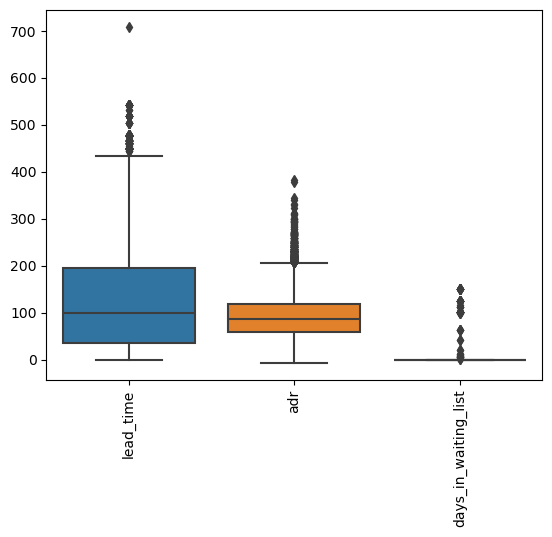


Box Plots to visualize outliers in quantitative data: 



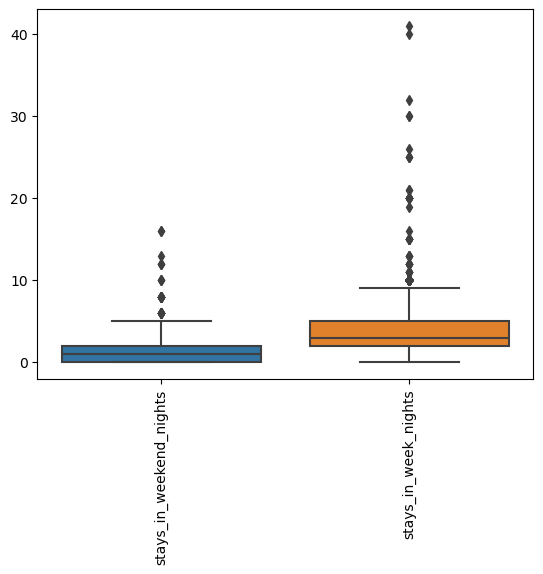


Box Plots to visualize outliers in quantitative data: 



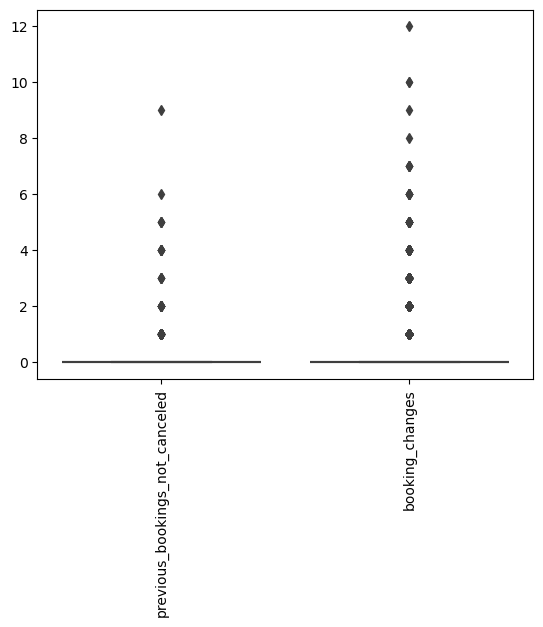


Box Plots to visualize outliers in quantitative data: 



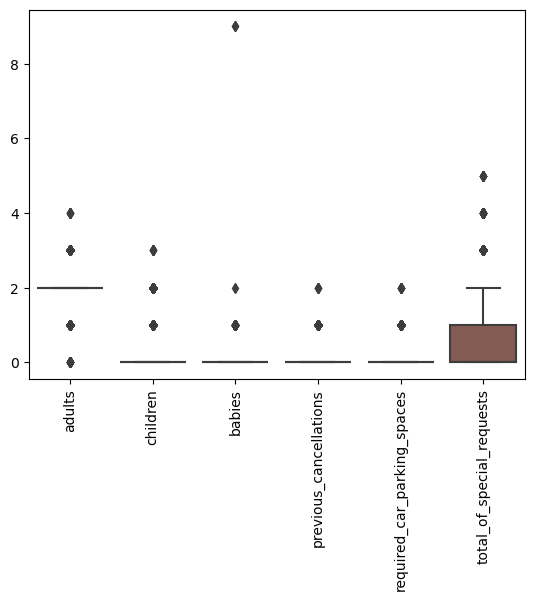


Bar chart of outlier counts by column: 



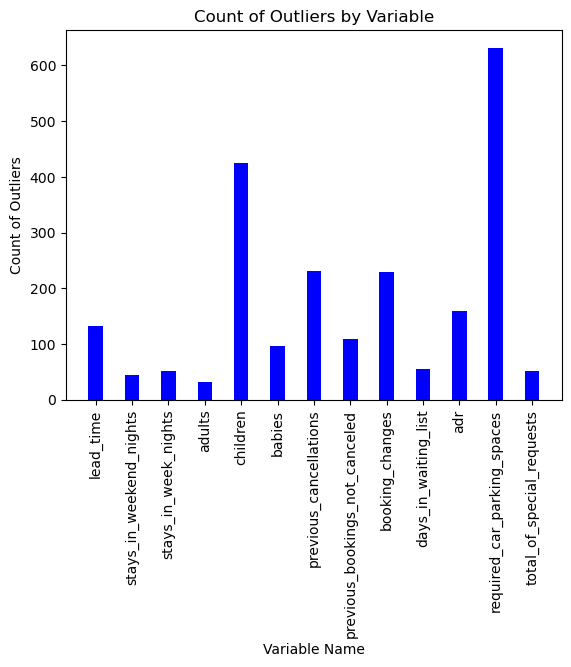

In [6]:
### Visualize Outliers ###

df_z_o_counts = pd.DataFrame([[z_lead_time_o_total,z_stays_in_weekend_nights_o_total,z_stays_in_week_nights_o_total,z_adults_o_total,
                              z_children_o_total,z_babies_o_total,z_previous_cancellations_o_total,z_previous_bookings_not_canceled_o_total,
                              z_booking_changes_o_total,z_days_in_waiting_list_o_total,z_adr_o_total,z_required_car_parking_spaces_o_total,
                              z_total_of_special_requests_o_total]],
                      columns=['lead_time','stays_in_weekend_nights','stays_in_week_nights','adults','children','babies','previous_cancellations','previous_bookings_not_canceled',
                              'booking_changes','days_in_waiting_list','adr','required_car_parking_spaces','total_of_special_requests'])
counts = list(df_z_o_counts.max())
columns = list(df_z_o_counts.columns)

# create box plots of categorical values
# Reference: https://www.tutorialspoint.com/rotate-xtick-labels-in-seaborn-boxplot-using-matplotlib

print("\nBox Plots to visualize outliers in quantitative data: \n")
xticks = [0, 1, 2]
ax = sns.boxplot(df[['lead_time','adr','days_in_waiting_list']])
ax.set_xticks(xticks)
ax.set_xticklabels(['lead_time','adr','days_in_waiting_list'], rotation=90)
plt.show()

print("\nBox Plots to visualize outliers in quantitative data: \n")
xticks = [0, 1]
ax = sns.boxplot(df[['stays_in_weekend_nights','stays_in_week_nights']])
ax.set_xticks(xticks)
ax.set_xticklabels(['stays_in_weekend_nights','stays_in_week_nights'], rotation=90)
plt.show()

print("\nBox Plots to visualize outliers in quantitative data: \n")
xticks = [0, 1]
ax = sns.boxplot(df[['previous_bookings_not_canceled','booking_changes']])
ax.set_xticks(xticks)
ax.set_xticklabels(['previous_bookings_not_canceled','booking_changes'], rotation=90)
plt.show()

print("\nBox Plots to visualize outliers in quantitative data: \n")
xticks = [0, 1, 2, 3, 4, 5]
ax = sns.boxplot(df[['adults','children','babies','previous_cancellations','required_car_parking_spaces','total_of_special_requests']])
ax.set_xticks(xticks)
ax.set_xticklabels(['adults','children','babies','previous_cancellations','required_car_parking_spaces','total_of_special_requests'], rotation=90)
plt.show()

# create bar chart of outlier counts
# Reference: https://www.geeksforgeeks.org/bar-plot-in-matplotlib/
print("\nBar chart of outlier counts by column: \n")
plt.bar(columns, counts, color ='blue', width = 0.4)
plt.xlabel("Variable Name")
plt.ylabel("Count of Outliers")
plt.title("Count of Outliers by Variable")
plt.xticks(rotation = 90)
plt.show()

In [7]:
# Convert outliers to missing, then impute new value.  Method = null out the value then impute a new one by the median.
# Only outliers that are more extreme will be imputed

def fix_outlier_int (column_name, outlier_min_value):
    df[column_name].where(df[column_name] < outlier_min_value, np.nan, inplace=True)

    df_impute_missing = df.copy(deep=True)
    df_impute_missing.drop(['hotel','arrival_date_month','meal','country','market_segment','distribution_channel','reserved_room_type',
                           'assigned_room_type','customer_type','reservation_status','reservation_status_date','deposit_type']
                           , axis=1,inplace=True)
    df_imputer = SimpleImputer(strategy='median')
    df_impute_missing.iloc[:,:] = df_imputer.fit_transform(df_impute_missing)

    # assign imputed values back to data frame
    # Reference: https://stackoverflow.com/questions/24768657/replace-column-values-based-on-another-dataframe-python-pandas-better-way
    df.loc[df.RecordID.isin(df_impute_missing.RecordID), [column_name]] = df_impute_missing.loc[df_impute_missing.RecordID.isin(df.RecordID),[column_name]].values.astype(int)

    # correct data types as needed
    print("Updated ", column_name, " unique values: ", df[column_name].unique())

def fix_outlier_float (column_name, outlier_min_value):
    df[column_name].where(df[column_name] < outlier_min_value, np.nan, inplace=True)

    df_impute_missing = df.copy(deep=True)
    df_impute_missing.drop(['hotel','arrival_date_month','meal','country','market_segment','distribution_channel','reserved_room_type',
                           'assigned_room_type','customer_type','reservation_status','reservation_status_date','deposit_type']
                           , axis=1,inplace=True)
    df_imputer = SimpleImputer(strategy='median')
    df_impute_missing.iloc[:,:] = df_imputer.fit_transform(df_impute_missing)

    # assign imputed values back to data frame
    # Reference: https://stackoverflow.com/questions/24768657/replace-column-values-based-on-another-dataframe-python-pandas-better-way
    df.loc[df.RecordID.isin(df_impute_missing.RecordID), [column_name]] = df_impute_missing.loc[df_impute_missing.RecordID.isin(df.RecordID),[column_name]].values.astype(float)

    # correct data types as needed
    print("Updated ", column_name, " unique values: ", df[column_name].unique())

#fix_outlier_int('lead_time',451)
fix_outlier_int('lead_time',542)
#fix_outlier_int('stays_in_weekend_nights',5)
#fix_outlier_int('stays_in_week_nights',11)
fix_outlier_int('stays_in_week_nights',32)
#fix_outlier_int('adults',3)
#fix_outlier_int('children',1)
#fix_outlier_int('babies',1)
fix_outlier_int('babies',8)
#fix_outlier_int('previous_cancellations',1)
#fix_outlier_int('previous_bookings_not_canceled',1)
fix_outlier_int('previous_bookings_not_canceled',8)
#fix_outlier_int('booking_changes',3)
fix_outlier_int('booking_changes',10)
#fix_outlier_int('days_in_waiting_list',43)
#fix_outlier_int('required_car_parking_spaces',1)
#fix_outlier_int('total_of_special_requests',4)
#fix_outlier_float('adr',231.778)

Updated  lead_time  unique values:  [259. 277. 283. 190. 287. 231.   7.  13.  14.  37. 127.  95.  90. 364.
  99. 324.  69.  12.  52.  92. 110.  96.  79. 258. 112. 100.  97. 111.
   0.  68. 394. 366. 106.  34.  41.  33.  59.  31.  48.  81.  91.  83.
  43.   6.   8.  28. 104.  29.  30.  89.  65.  55.  35.  67.  61.  60.
  45.  38.  76.  70.  71. 102.  17. 460.   4.  66.  80.  57.  98.  10.
 103.   5. 123.  73. 381.  56.  50. 327.  26.  74.  47. 356. 115. 328.
 144. 248. 117. 160. 175. 382. 118.   1. 170.  82. 338.   3. 157.  11.
 165. 136. 137. 173.  21. 107. 135. 124. 119. 114. 138.  87. 131. 167.
  85.  75. 128.  86. 125.  93.  94. 109.  84.  77.  44. 116.  53. 177.
  51. 163.  58.  78. 145.  63. 192.  25.  54. 207. 158.  22.  19.  27.
 150.  88.   9.  40. 108.  24.  36. 133. 120.  72.  62.   2.  39. 146.
  49.  46. 174. 130. 183. 126. 194. 261. 155. 101. 245. 280. 289. 152.
 143. 189. 134. 129. 151. 237. 184. 188. 162. 241. 201. 153. 142. 296.
  20.  64. 311. 156. 310. 217. 211. 164. 

###  is_canceled  ###

Value Counts:
 0    10918
1     2569
Name: is_canceled, dtype: int64 

Percent of Total:
 0    80.952028
1    19.047972
Name: is_canceled, dtype: float64 



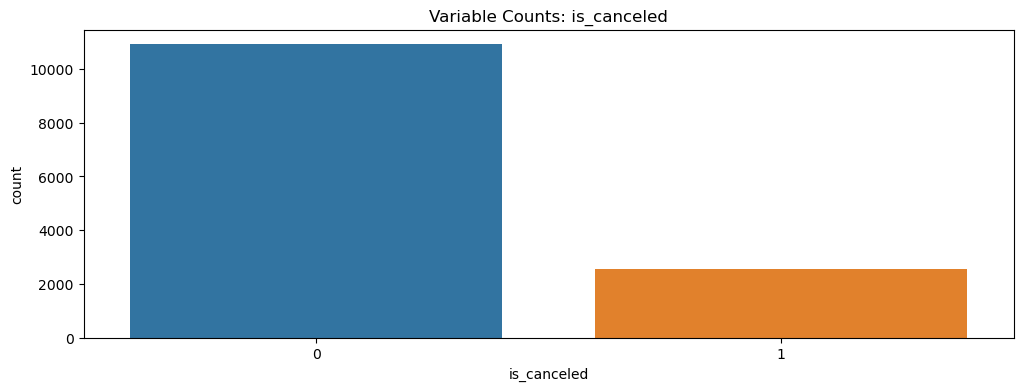

###  is_repeated_guest  ###

Value Counts:
 0    13376
1      111
Name: is_repeated_guest, dtype: int64 

Percent of Total:
 0    99.176985
1     0.823015
Name: is_repeated_guest, dtype: float64 



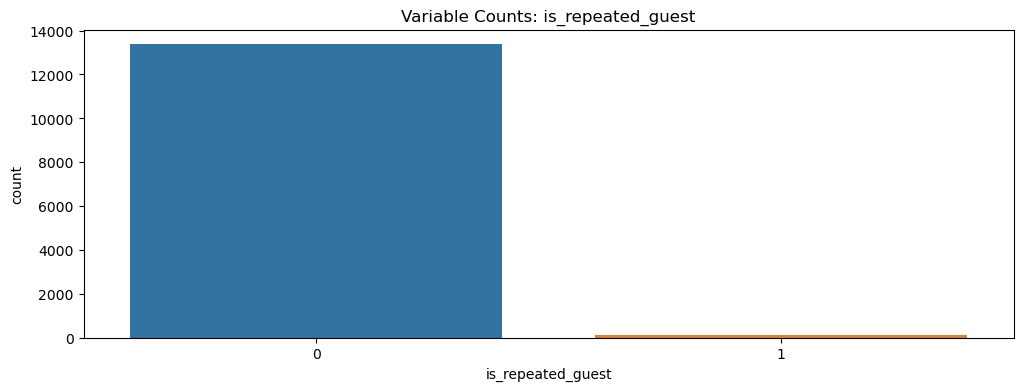

###  hotel  ###

Value Counts:
 Resort Hotel    7926
City Hotel      5561
Name: hotel, dtype: int64 

Percent of Total:
 Resort Hotel    58.767702
City Hotel      41.232298
Name: hotel, dtype: float64 



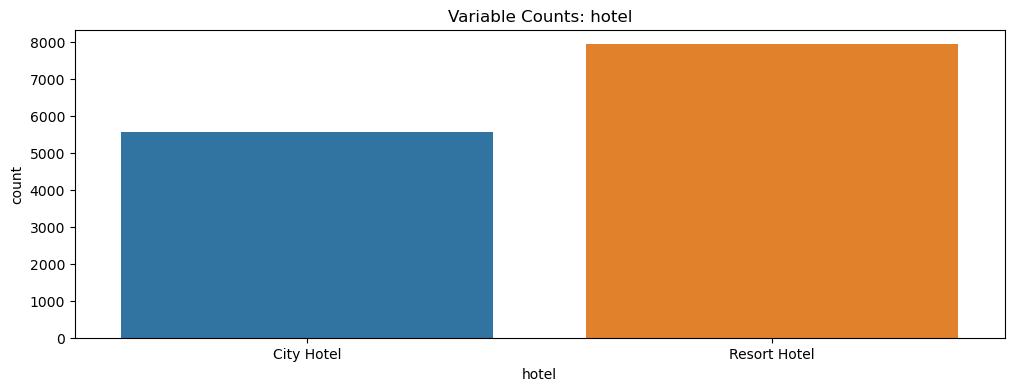

###  arrival_date_month  ###

Value Counts:
 October      1787
May          1557
September    1529
July         1480
June         1378
August       1310
April        1147
March         988
February      794
November      649
December      501
January       367
Name: arrival_date_month, dtype: int64 

Percent of Total:
 October      13.249796
May          11.544450
September    11.336843
July         10.973530
June         10.217246
August        9.713057
April         8.504486
March         7.325573
February      5.887151
November      4.812041
December      3.714688
January       2.721139
Name: arrival_date_month, dtype: float64 



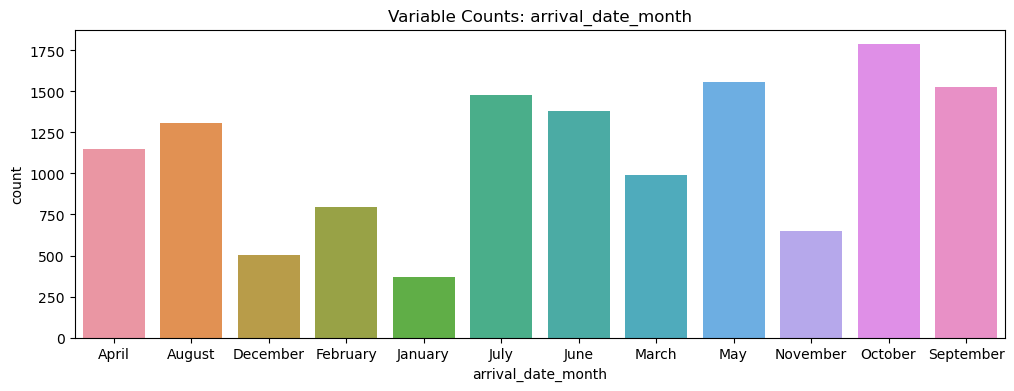

###  meal  ###

Value Counts:
 BB           10125
HB            1866
SC            1451
FB              25
Undefined       20
Name: meal, dtype: int64 

Percent of Total:
 BB           75.072292
HB           13.835545
SC           10.758508
FB            0.185364
Undefined     0.148291
Name: meal, dtype: float64 



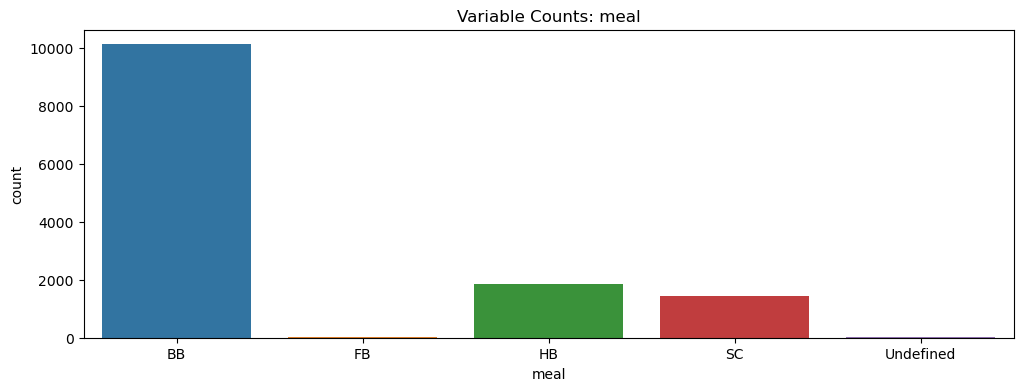

###  country  ###

Value Counts:
 GBR    13487
Name: country, dtype: int64 

Percent of Total:
 GBR    100.0
Name: country, dtype: float64 



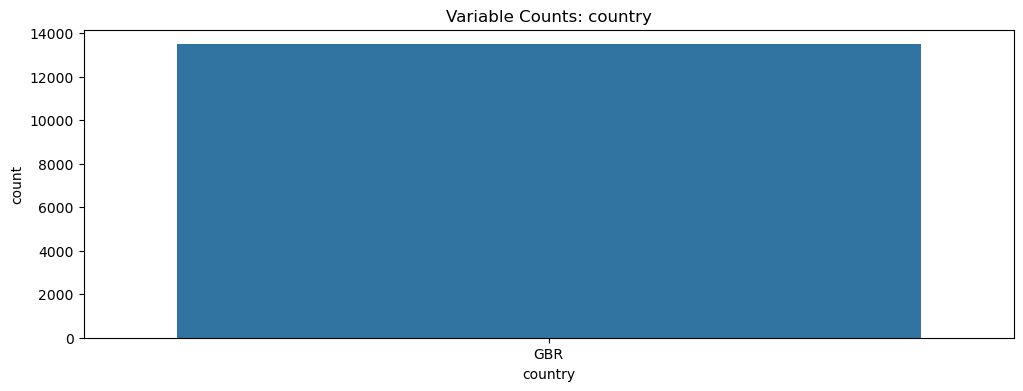

###  market_segment  ###

Value Counts:
 Online TA        6944
Offline TA/TO    3638
Groups           1789
Direct            948
Corporate         143
Complementary      21
Aviation            4
Name: market_segment, dtype: int64 

Percent of Total:
 Online TA        51.486617
Offline TA/TO    26.974123
Groups           13.264625
Direct            7.028991
Corporate         1.060280
Complementary     0.155705
Aviation          0.029658
Name: market_segment, dtype: float64 



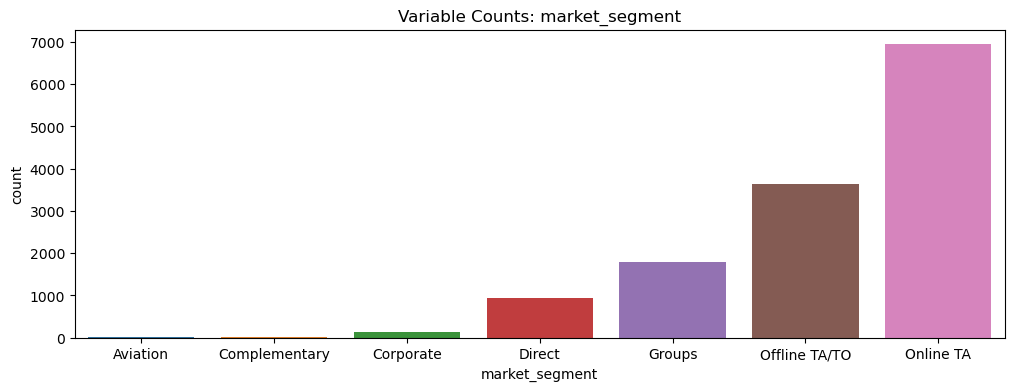

###  distribution_channel  ###

Value Counts:
 TA/TO        11254
Direct        1407
Corporate      804
GDS             22
Name: distribution_channel, dtype: int64 

Percent of Total:
 TA/TO        83.443316
Direct       10.432268
Corporate     5.961296
GDS           0.163120
Name: distribution_channel, dtype: float64 



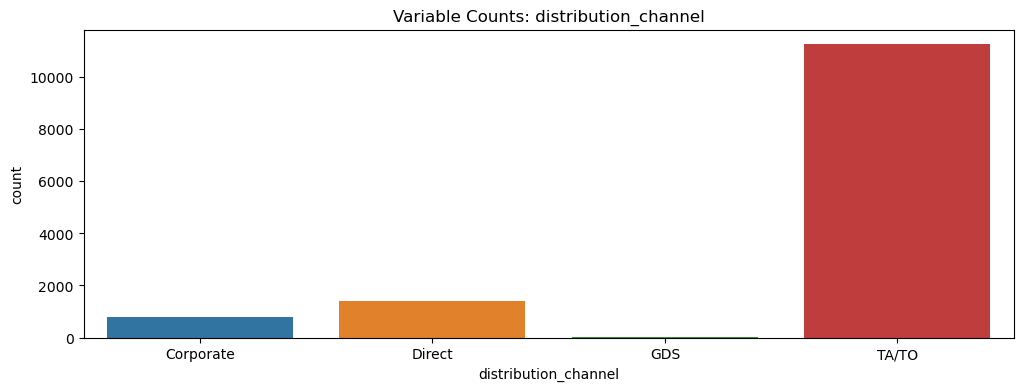

###  reserved_room_type  ###

Value Counts:
 A    8032
D    3249
E    1265
F     389
G     282
C     110
B      91
H      69
Name: reserved_room_type, dtype: int64 

Percent of Total:
 A    59.553644
D    24.089864
E     9.379402
F     2.884259
G     2.090902
C     0.815600
B     0.674724
H     0.511604
Name: reserved_room_type, dtype: float64 



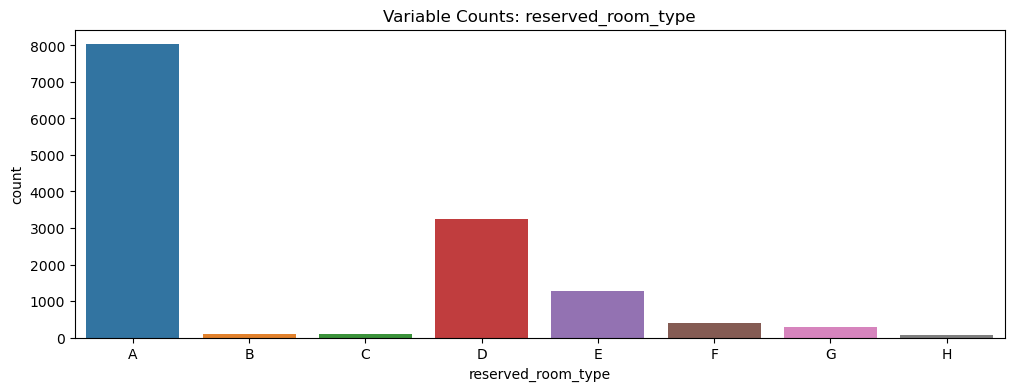

###  assigned_room_type  ###

Value Counts:
 A    6717
D    3686
E    1493
F     544
C     400
G     326
B     157
H      89
I      62
K      13
Name: assigned_room_type, dtype: int64 

Percent of Total:
 A    49.803514
D    27.330022
E    11.069919
F     4.033514
C     2.965819
G     2.417142
B     1.164084
H     0.659895
I     0.459702
K     0.096389
Name: assigned_room_type, dtype: float64 



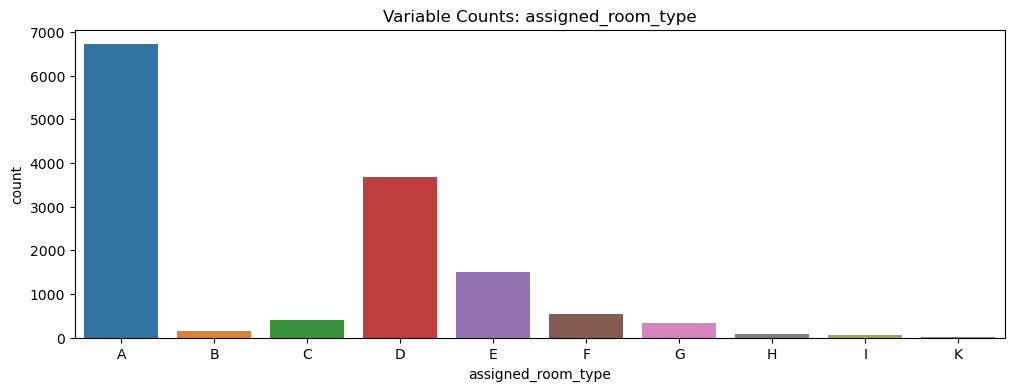

###  customer_type  ###

Value Counts:
 Transient          9276
Transient-Party    2372
Contract           1735
Group               104
Name: customer_type, dtype: int64 

Percent of Total:
 Transient          68.777341
Transient-Party    17.587306
Contract           12.864240
Group               0.771113
Name: customer_type, dtype: float64 



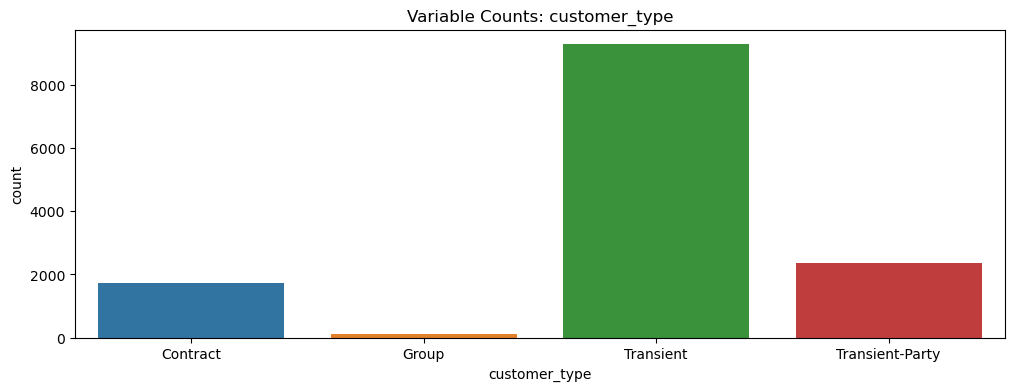

###  reservation_status  ###

Value Counts:
 Check-Out    10918
Canceled      2528
No-Show         41
Name: reservation_status, dtype: int64 

Percent of Total:
 Check-Out    80.952028
Canceled     18.743976
No-Show       0.303996
Name: reservation_status, dtype: float64 



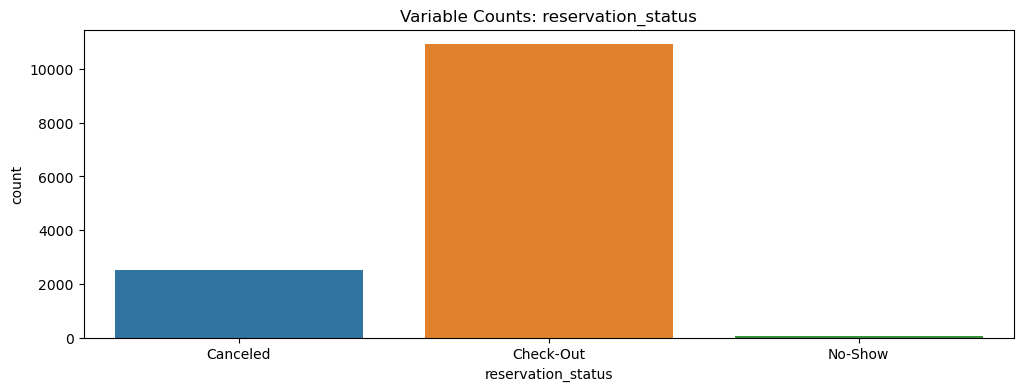

###  reservation_status_date  ###

Value Counts:
 1/21/2019     96
10/19/2019    94
1/21/2018     90
10/19/2018    84
10/9/2019     78
              ..
5/20/2018      1
12/7/2018      1
9/14/2020      1
12/24/2018     1
12/25/2019     1
Name: reservation_status_date, Length: 800, dtype: int64 

Percent of Total:
 1/21/2019     0.711797
10/19/2019    0.696967
1/21/2018     0.667309
10/19/2018    0.622822
10/9/2019     0.578335
                ...   
5/20/2018     0.007415
12/7/2018     0.007415
9/14/2020     0.007415
12/24/2018    0.007415
12/25/2019    0.007415
Name: reservation_status_date, Length: 800, dtype: float64 



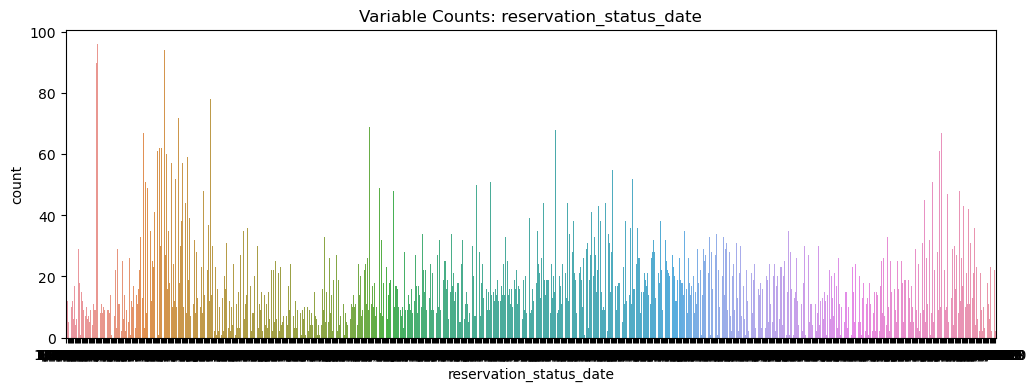

###  deposit_type  ###

Value Counts:
 No Deposit    13168
Non Refund      245
Refundable       74
Name: deposit_type, dtype: int64 

Percent of Total:
 No Deposit    97.634759
Non Refund     1.816564
Refundable     0.548677
Name: deposit_type, dtype: float64 



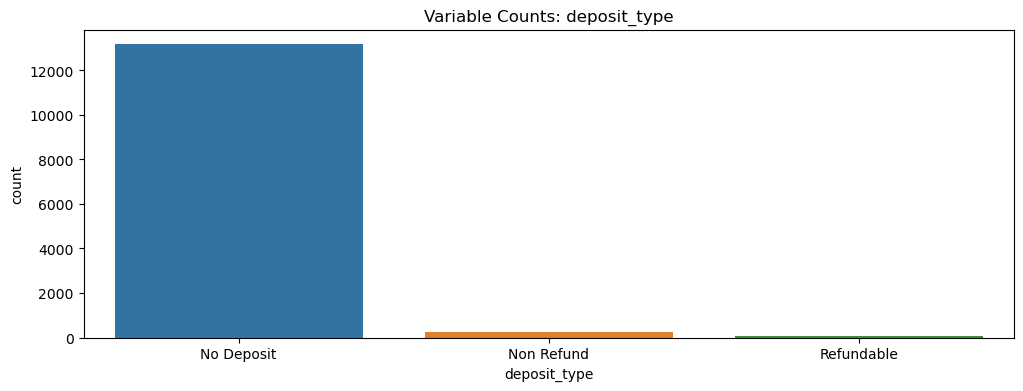

###  lead_time  ###

Mean: 125.63
Median: 99.0
Min: 0.0
Max: 532.0
Standard Deviation: 105.86157024416401



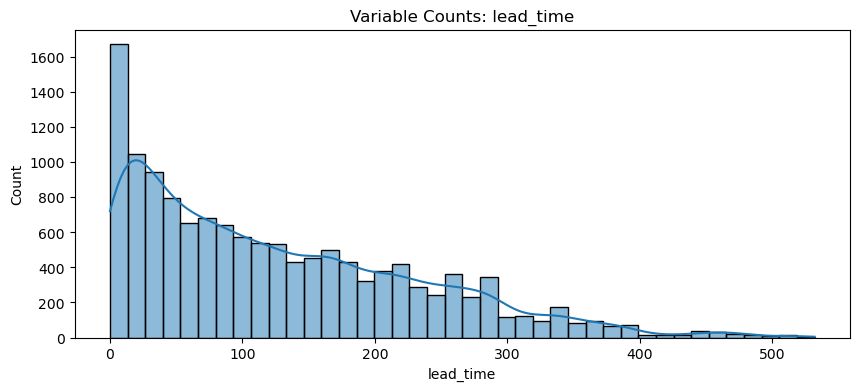

###  arrival_date_year  ###

Mean: 2019.28
Median: 2019.0
Min: 2018
Max: 2020
Standard Deviation: 0.636011554139725



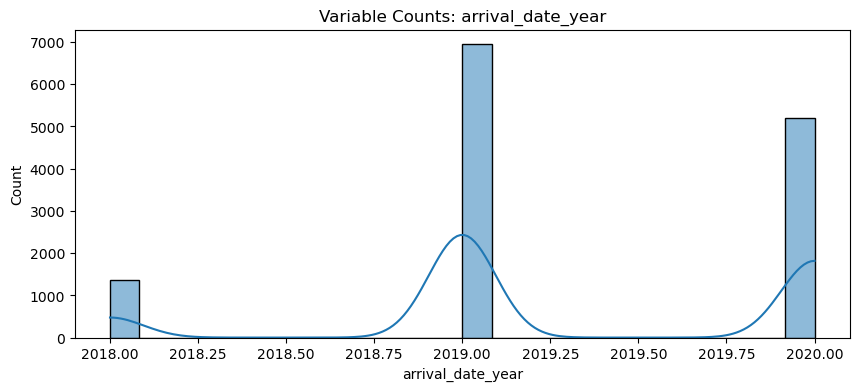

###  arrival_date_week_number  ###

Mean: 28.03
Median: 28.0
Min: 1
Max: 53
Standard Deviation: 12.780783712595921



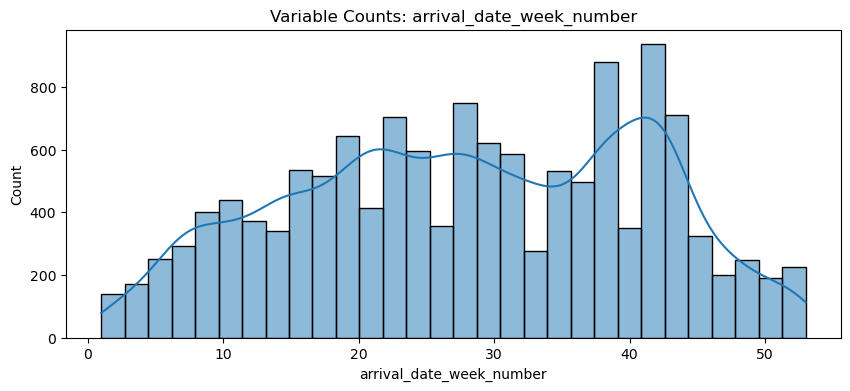

###  arrival_date_day_of_month  ###

Mean: 15.69
Median: 16.0
Min: 1
Max: 31
Standard Deviation: 8.524297989158352



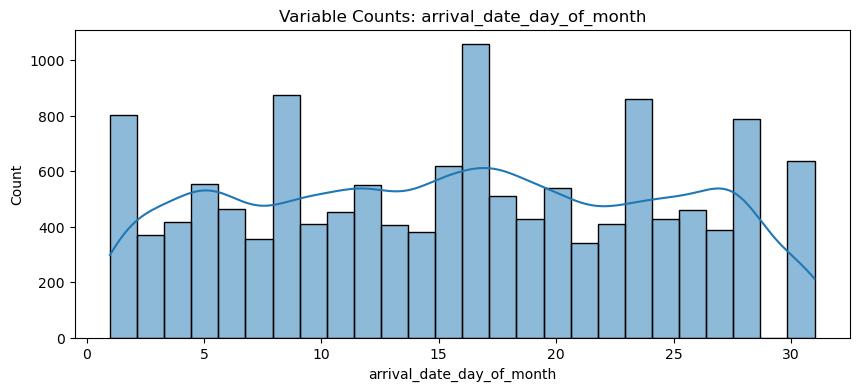

###  stays_in_weekend_nights  ###

Mean: 1.37
Median: 1.0
Min: 0
Max: 16
Standard Deviation: 1.1616930086722541



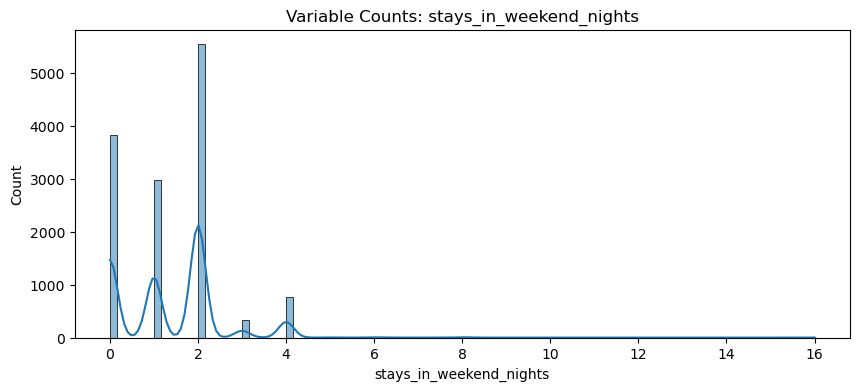

###  stays_in_week_nights  ###

Mean: 3.51
Median: 3.0
Min: 0.0
Max: 30.0
Standard Deviation: 2.336368910078993



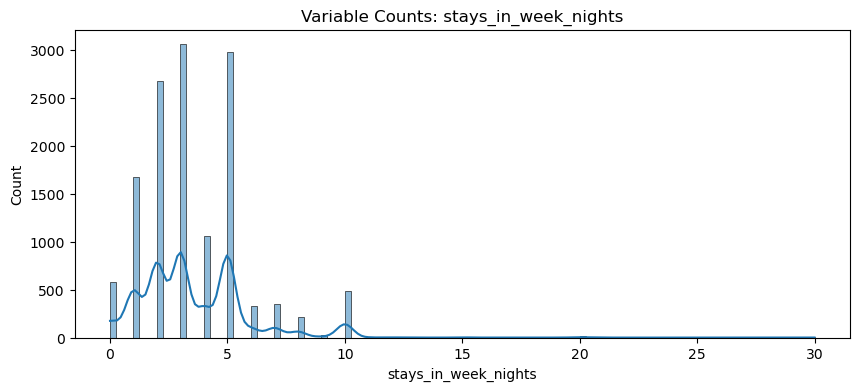

###  adults  ###

Mean: 1.91
Median: 2.0
Min: 0
Max: 4
Standard Deviation: 0.4392744957698547



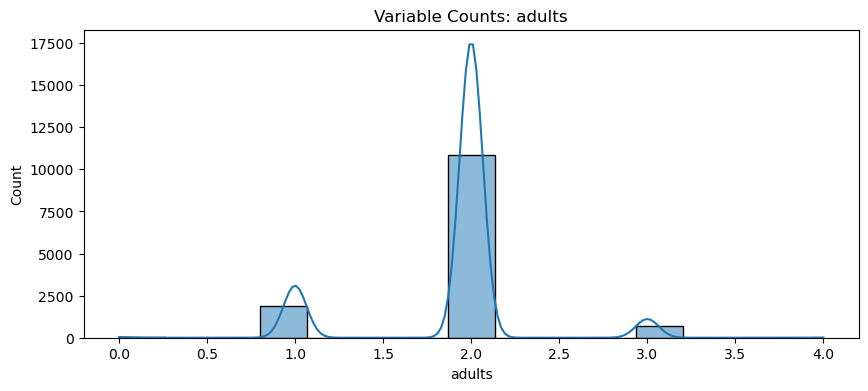

###  children  ###

Mean: 0.1
Median: 0.0
Min: 0.0
Max: 3.0
Standard Deviation: 0.3907555037813266



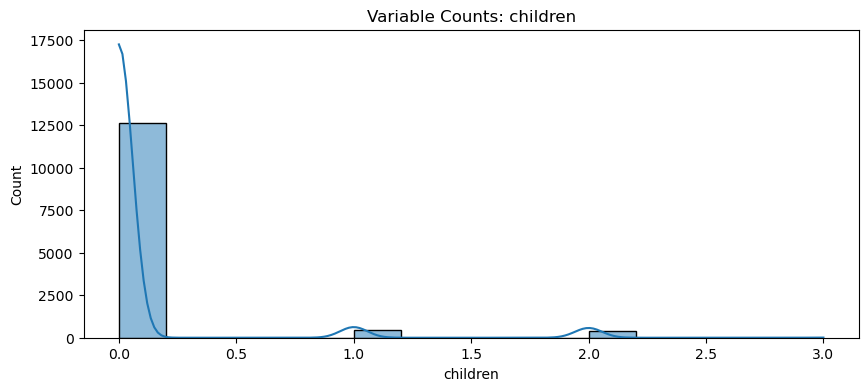

###  babies  ###

Mean: 0.01
Median: 0.0
Min: 0.0
Max: 2.0
Standard Deviation: 0.08494778399701869



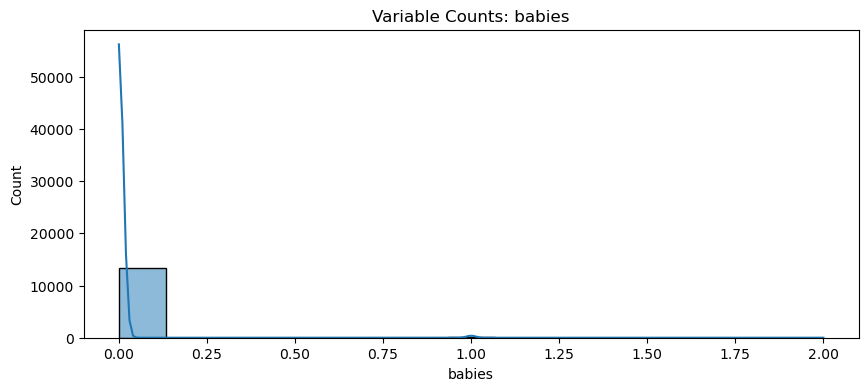

###  previous_cancellations  ###

Mean: 0.02
Median: 0.0
Min: 0
Max: 2
Standard Deviation: 0.13282879521069868



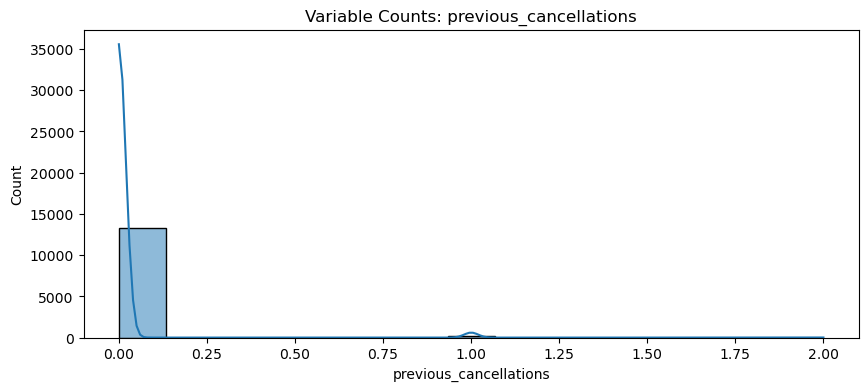

###  previous_bookings_not_canceled  ###

Mean: 0.01
Median: 0.0
Min: 0.0
Max: 6.0
Standard Deviation: 0.17954275118046256



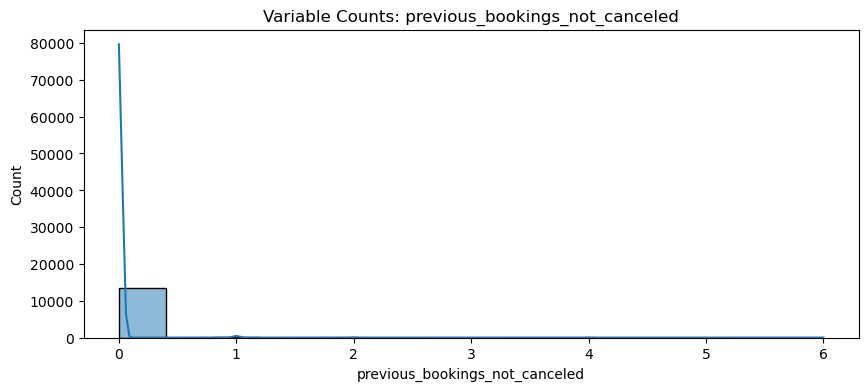

###  booking_changes  ###

Mean: 0.27
Median: 0.0
Min: 0.0
Max: 9.0
Standard Deviation: 0.6825744722903296



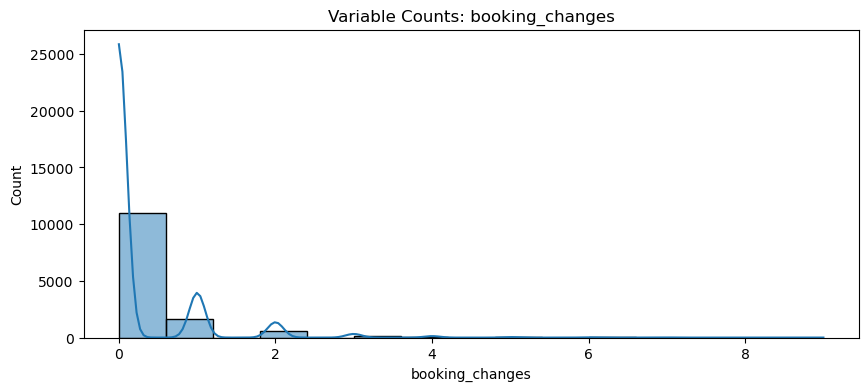

###  days_in_waiting_list  ###

Mean: 0.47
Median: 0.0
Min: 0
Max: 150
Standard Deviation: 7.418017871322167



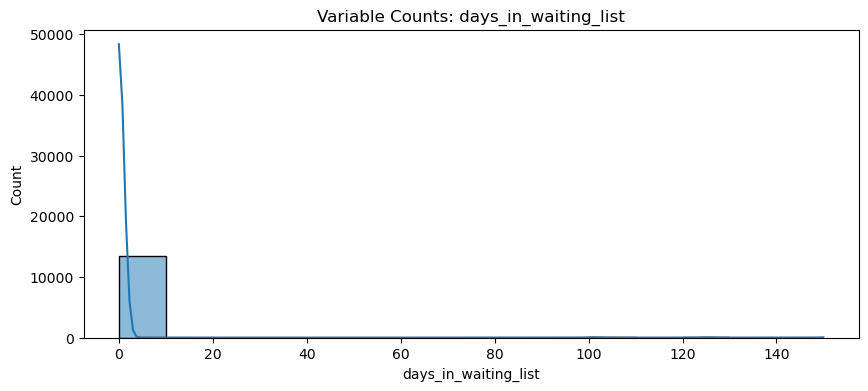

###  adr  ###

Mean: 94.01
Median: 87.04
Min: -6.38
Max: 382.0
Standard Deviation: 45.86590204679888



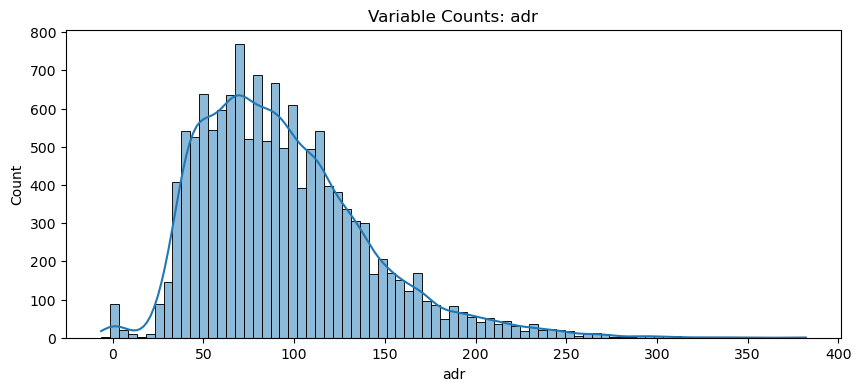

###  required_car_parking_spaces  ###

Mean: 0.05
Median: 0.0
Min: 0
Max: 2
Standard Deviation: 0.21488520712913015



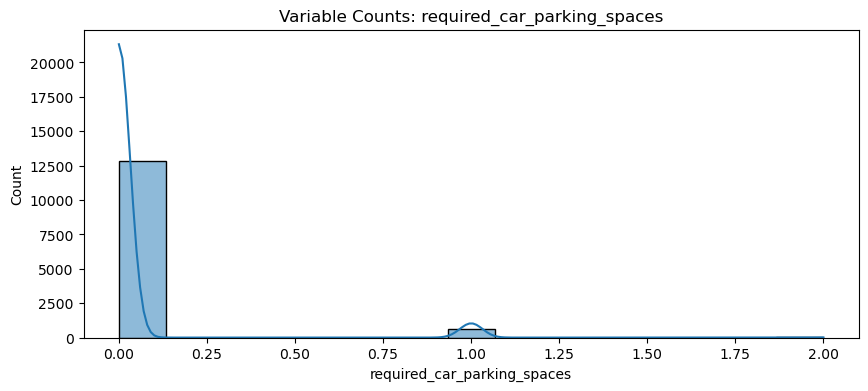

###  total_of_special_requests  ###

Mean: 0.67
Median: 0.0
Min: 0
Max: 5
Standard Deviation: 0.8226138193970287



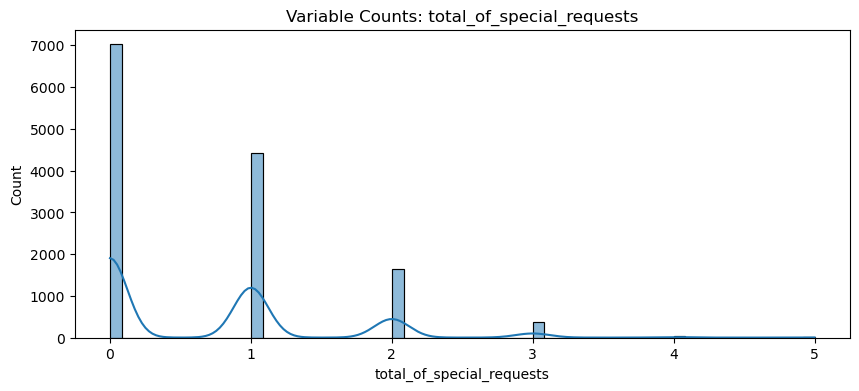

In [8]:
############### Data Exporation - Summary Statistics and Univariate Visualizations ###############
categorical_list = ['is_canceled','is_repeated_guest','hotel','arrival_date_month','meal','country','market_segment','distribution_channel','reserved_room_type',
                           'assigned_room_type','customer_type','reservation_status','reservation_status_date','deposit_type']

quantitative_list = ['lead_time','arrival_date_year','arrival_date_week_number','arrival_date_day_of_month','stays_in_weekend_nights','stays_in_week_nights',
                      'adults','children','babies','previous_cancellations','previous_bookings_not_canceled','booking_changes','days_in_waiting_list','adr',
                      'required_car_parking_spaces','total_of_special_requests']
def var_summary (is_categorical, variable_name):
    variable_name = variable_name.sort_values()
    print('### ', variable_name.name, ' ###\n')
    if is_categorical==0:
        print('Mean: ' + str(round(np.mean(variable_name),2)) + '\n'
              + 'Median: ' + str(round(np.median(variable_name),2)) + '\n'
              + 'Min: ' + str(round(np.min(variable_name),2)) + '\n'
              + 'Max: ' + str(round(np.max(variable_name),2)) + '\n'
              + 'Standard Deviation: ' + str(stats.stdev(variable_name)) + '\n'
             )
        plt.figure(figsize=(10,4))
        sns.histplot(data=variable_name, fill=True, kde=True)
        plt.title('Variable Counts: {}'.format(variable_name.name))
        plt.show()
        
    if is_categorical==1:
        print("Value Counts:\n", pd.Series(variable_name).value_counts(), '\n')
        print("Percent of Total:\n", pd.Series(variable_name).value_counts()/len(df)*100, '\n')
        plt.figure(figsize=(12,4))
        sns.countplot(x=variable_name)
        plt.title('Variable Counts: {}'.format(variable_name.name))
        plt.show()

i = 0
while i < len(categorical_list):
  var_summary(1, df[categorical_list[i]])
  i = i + 1

i = 0
while i < len(quantitative_list):
  var_summary(0, df[quantitative_list[i]])
  i = i + 1    

In [9]:
# Remove columns that are now the same after data cleaning
df.drop(['country'],axis=1,inplace=True)

categorical_list = ['is_repeated_guest','hotel','arrival_date_month','meal','market_segment','distribution_channel','reserved_room_type',
                           'assigned_room_type','customer_type','reservation_status','reservation_status_date','deposit_type']

quantitative_list = ['lead_time','arrival_date_year','arrival_date_week_number','arrival_date_day_of_month','stays_in_weekend_nights',
                     'stays_in_week_nights','babies','previous_cancellations', 'adults','booking_changes','days_in_waiting_list','adr',
                     'required_car_parking_spaces','total_of_special_requests','previous_bookings_not_canceled','children']

###  is_repeated_guest  ###



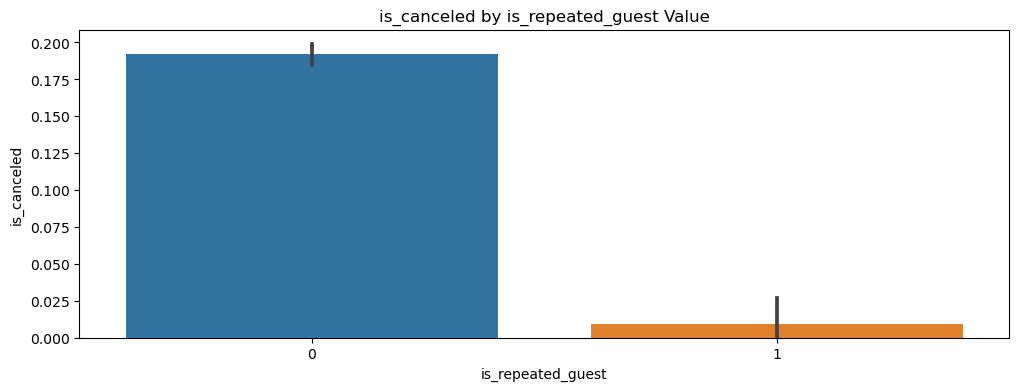

###  hotel  ###



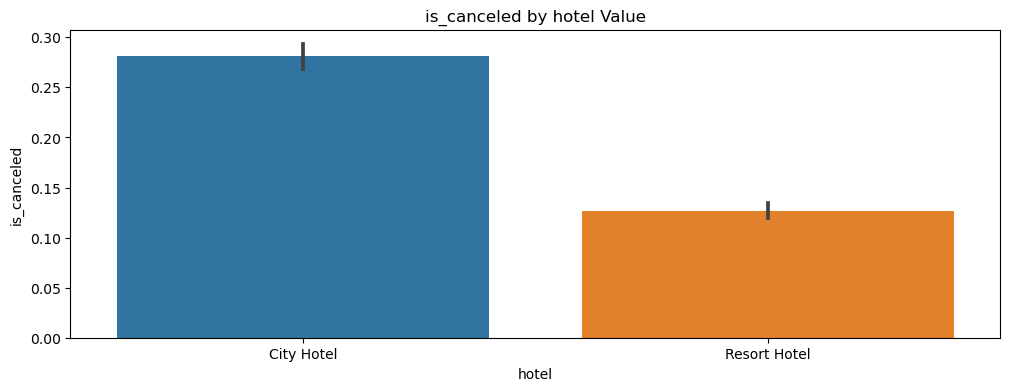

###  arrival_date_month  ###



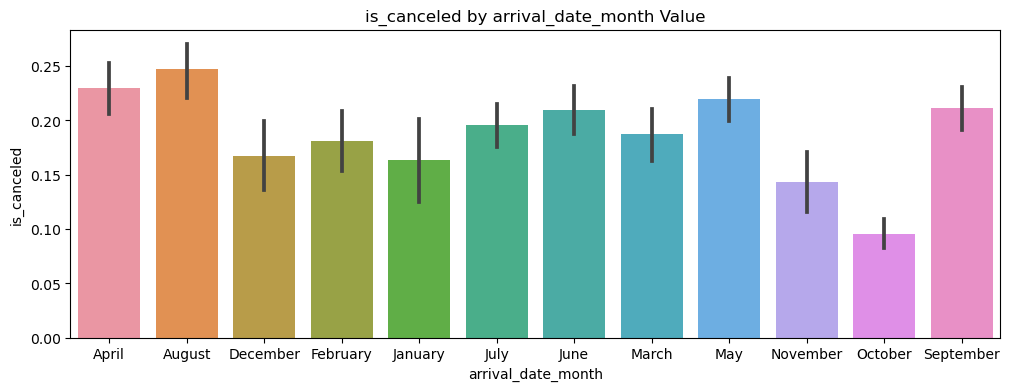

###  meal  ###



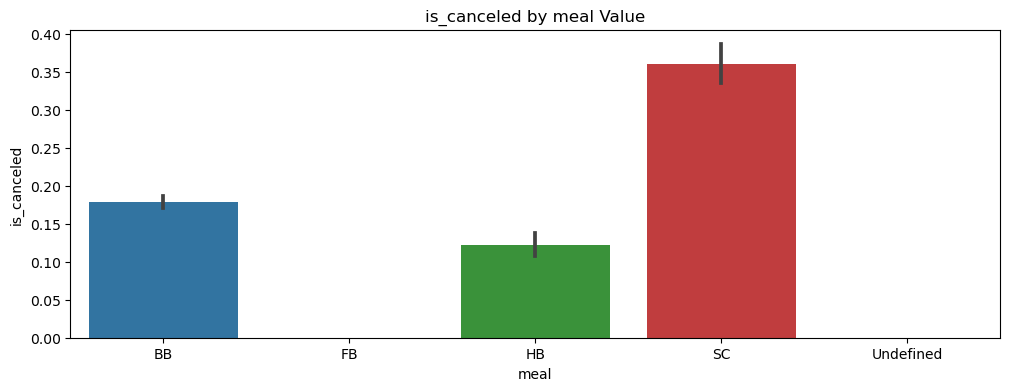

###  market_segment  ###



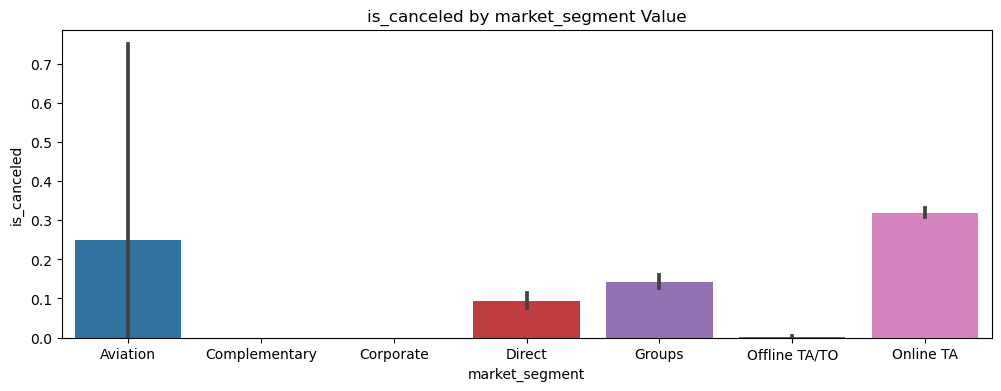

###  distribution_channel  ###



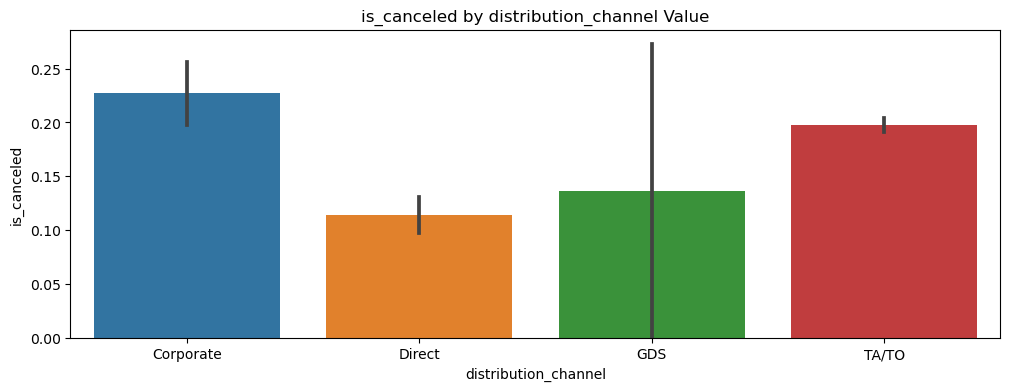

###  reserved_room_type  ###



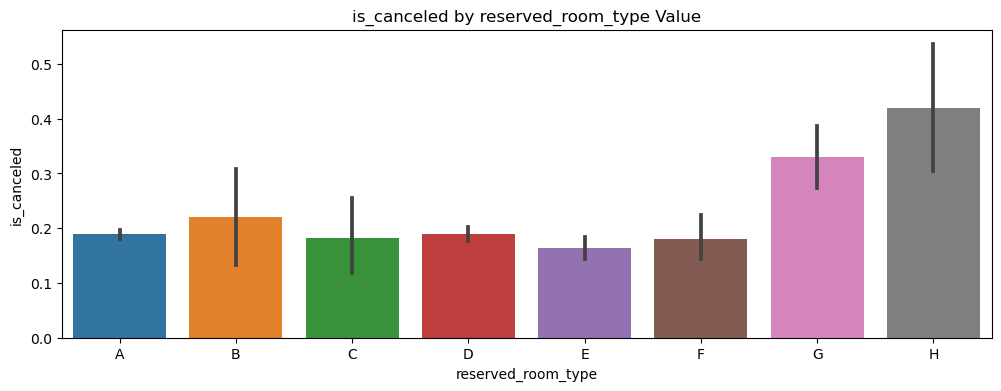

###  assigned_room_type  ###



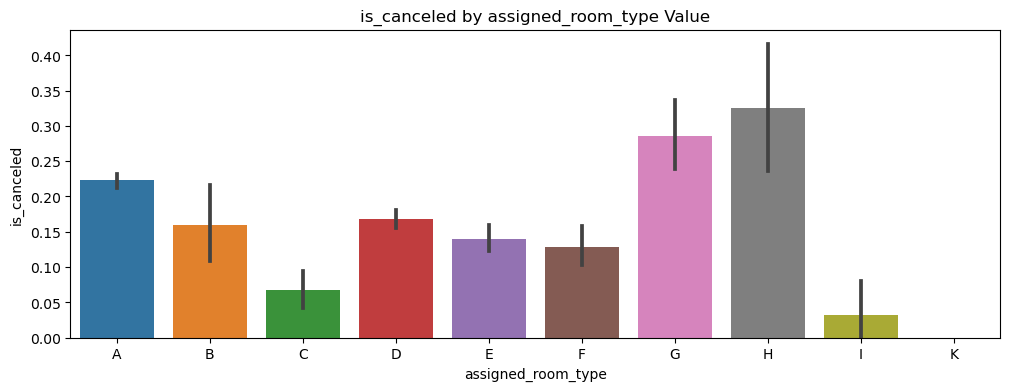

###  customer_type  ###



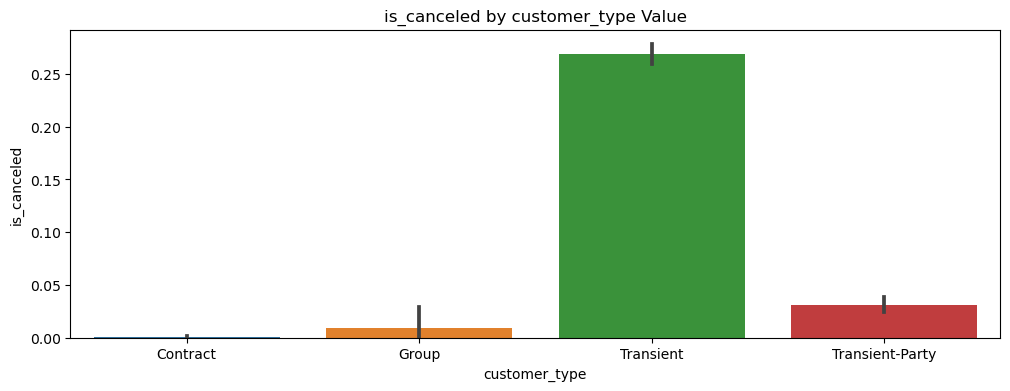

###  reservation_status  ###



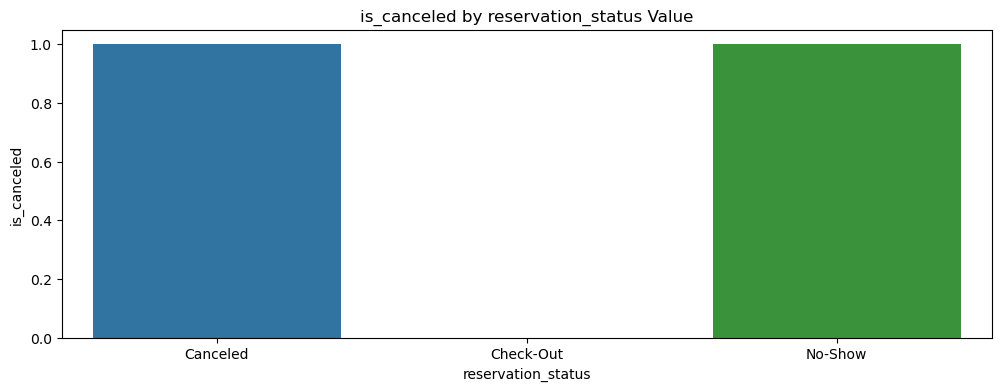

###  reservation_status_date  ###



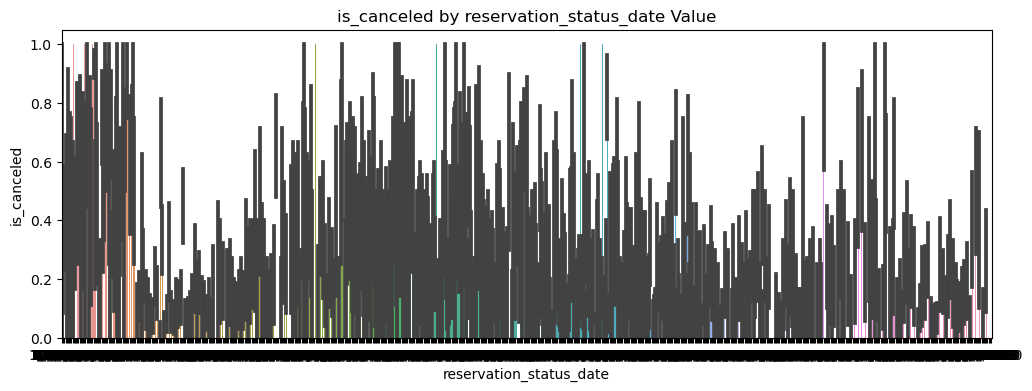

###  deposit_type  ###



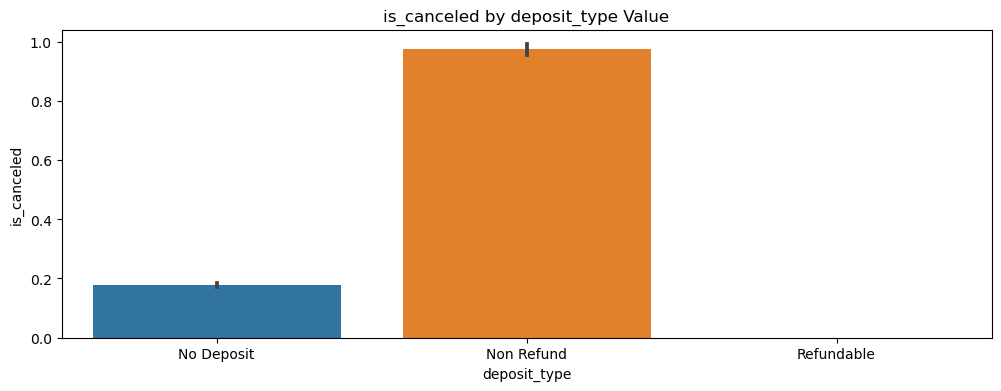

###  lead_time  ###



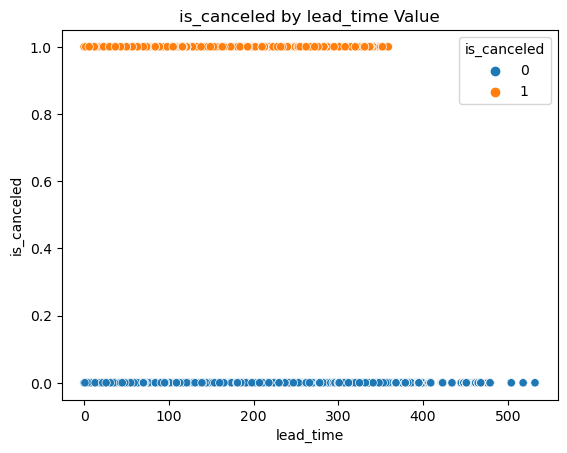

###  arrival_date_year  ###



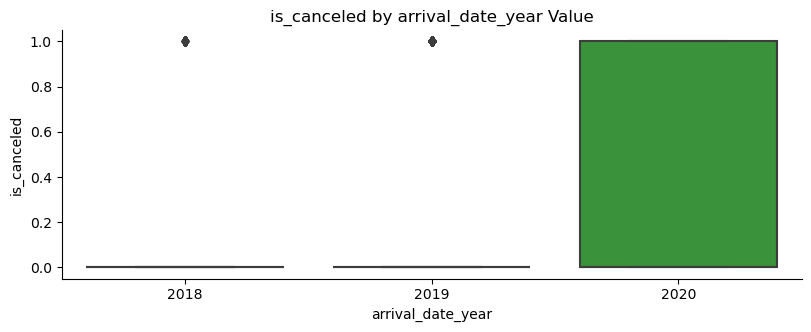

###  arrival_date_week_number  ###



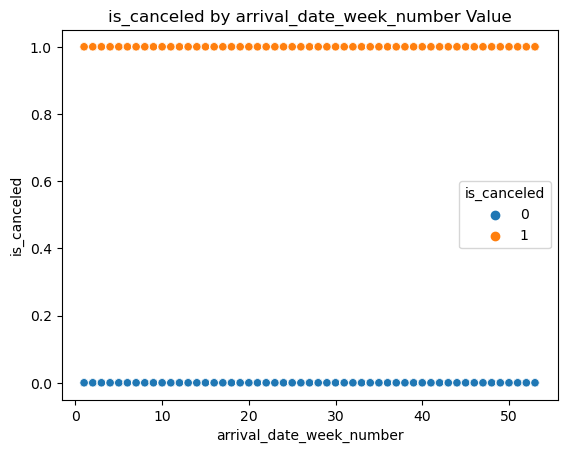

###  arrival_date_day_of_month  ###



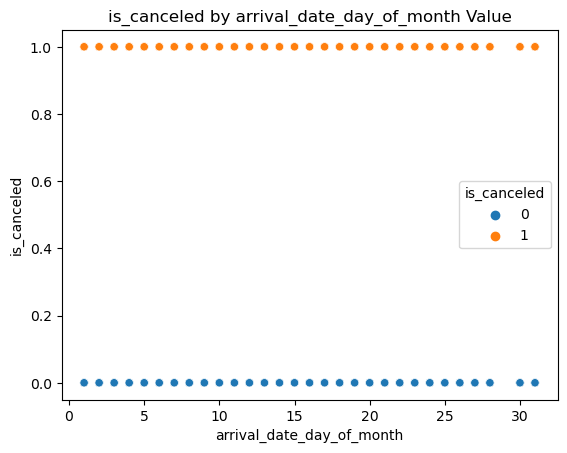

###  stays_in_weekend_nights  ###



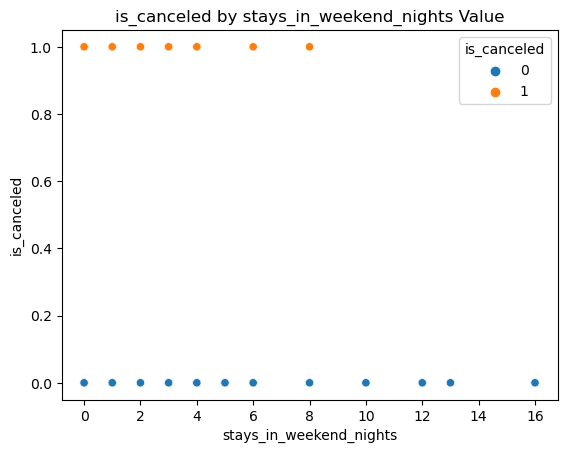

###  stays_in_week_nights  ###



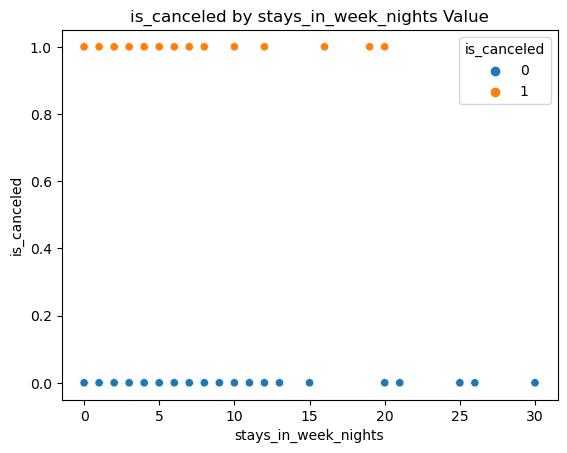

###  babies  ###



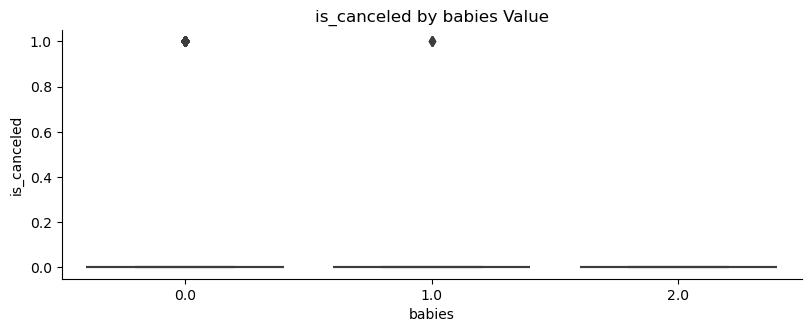

###  previous_cancellations  ###



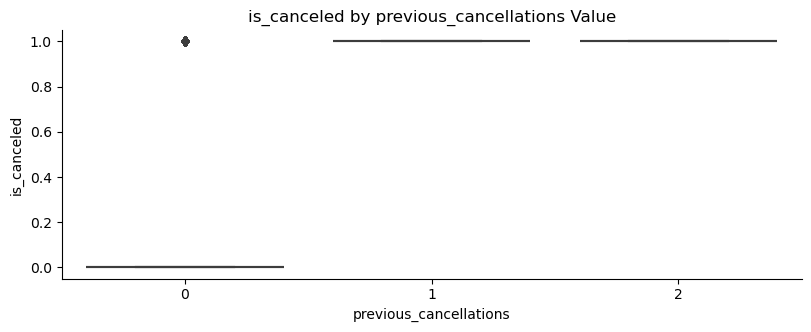

###  adults  ###



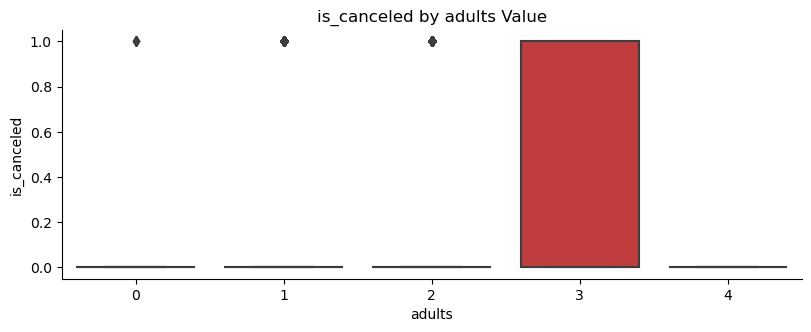

###  booking_changes  ###



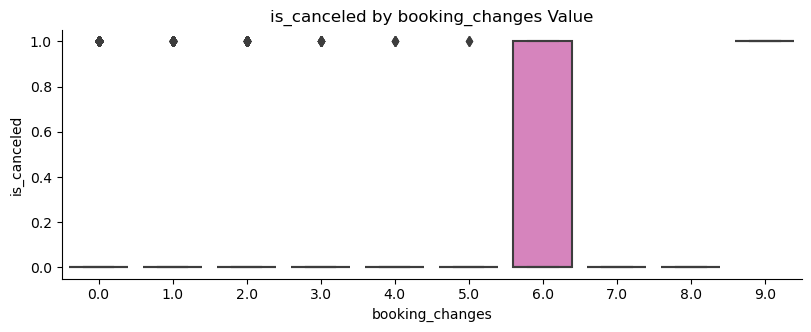

###  days_in_waiting_list  ###



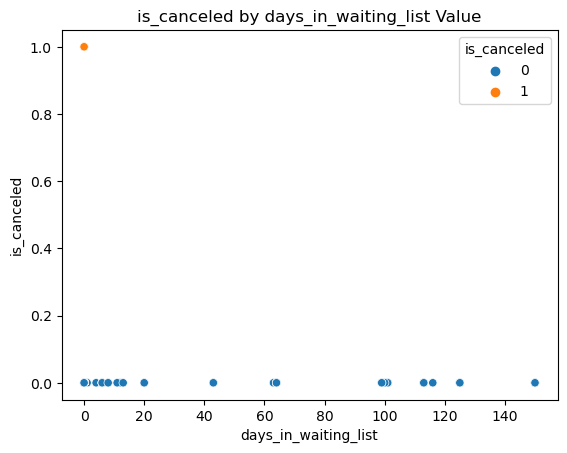

###  adr  ###



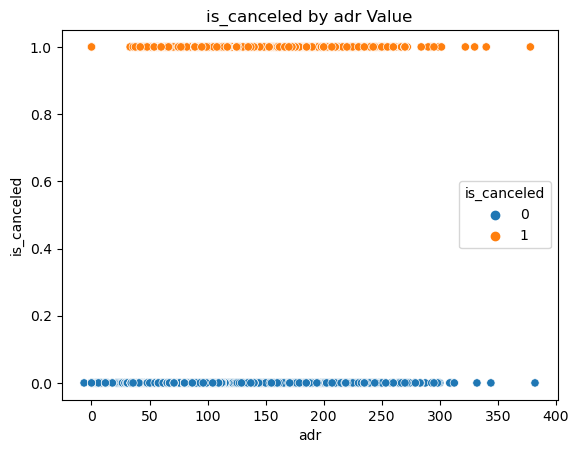

###  required_car_parking_spaces  ###



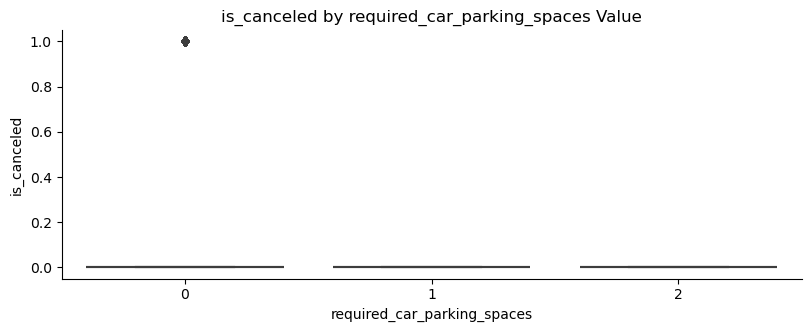

###  total_of_special_requests  ###



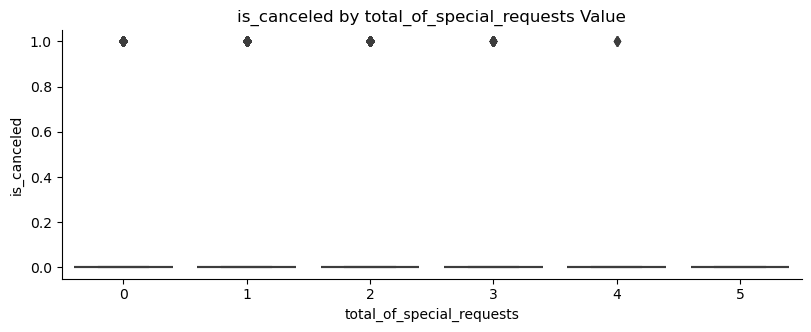

###  previous_bookings_not_canceled  ###



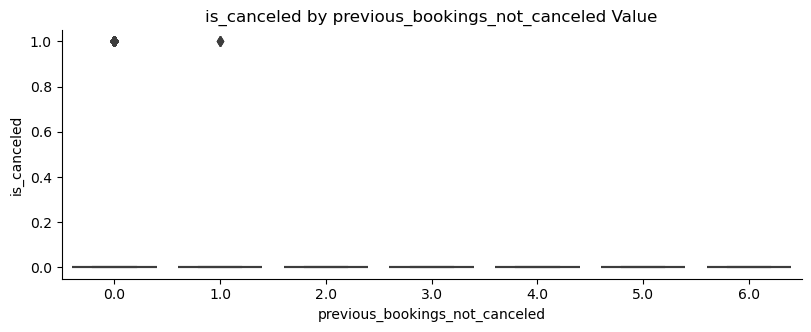

###  children  ###



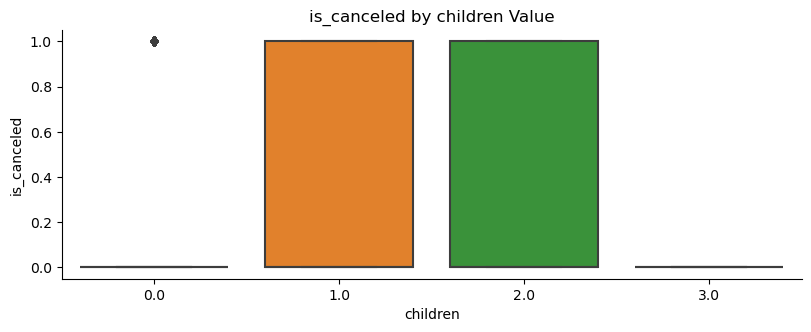

In [10]:
############### Data Exploration - Bivariate Visualizations ###############

def bivar_summary (ind_var, is_ind_var_categorical, dep_var):
    ind_var = ind_var.sort_values()
    print('### ', ind_var.name, ' ###\n')
    if is_ind_var_categorical==0:
        if ind_var.max() - ind_var.min() > 10:
            sns.scatterplot(data=df, x=ind_var, y=dep_var, hue=dep_var)
        else:
            sns.catplot(data=df, x=ind_var, y=dep_var, kind="box", height=5, aspect=2)
         
    if is_ind_var_categorical==1:
        plt.figure(figsize=(12,4))
        sns.barplot(data=df, x=ind_var, y=dep_var)
          
    plt.title('{} by {} Value'.format(dep_var.name, ind_var.name))
    plt.show()

dependent_variable = df['is_canceled']

i = 0
while i < len(categorical_list):
  bivar_summary(df[categorical_list[i]], 1, dependent_variable)
  i = i + 1
    
i = 0
while i < len(quantitative_list):
  bivar_summary(df[quantitative_list[i]], 0, dependent_variable)
  i = i + 1  

In [11]:
# Set No-Shows to is_canceled = 1
df['is_canceled'] = df.apply(lambda x: x['is_canceled'] if x['reservation_status'] == "No-Show" else x['is_canceled'], axis=1)

# Remove reservation_status because it has a 1:1 correlation with is_canceled
df.drop(['reservation_status'],axis=1, inplace=True)

# Remove reservation_status_date because it is not a good fit for the logistic regression model requirements.  One-hot encoding the value would 
# create an excessive number of columns, but it also is not truly numeric and the intent of this study is not to perform time series analysis.
df.drop(['reservation_status_date'],axis=1, inplace=True)

# Remove columns used to calculate and address outliers
df.drop(['z_lead_time','z_lead_time_o','z_arrival_date_year','z_arrival_date_year_o','z_arrival_date_week_number','z_arrival_date_week_number_o','z_arrival_date_day_of_month',
         'z_arrival_date_day_of_month_o','z_stays_in_weekend_nights','z_stays_in_weekend_nights_o','z_stays_in_week_nights','z_stays_in_week_nights_o','z_adults','z_adults_o',
         'z_children','z_children_o','z_babies','z_babies_o','z_previous_cancellations','z_previous_cancellations_o','z_previous_bookings_not_canceled','z_previous_bookings_not_canceled_o',
         'z_booking_changes','z_booking_changes_o','z_days_in_waiting_list','z_days_in_waiting_list_o','z_adr','z_adr_o','z_required_car_parking_spaces','z_required_car_parking_spaces_o',
         'z_total_of_special_requests','z_total_of_special_requests_o'], axis=1, inplace=True)

# confirm clean datafram structure
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13487 entries, 0 to 13486
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   RecordID                        13487 non-null  int64  
 1   hotel                           13487 non-null  object 
 2   is_canceled                     13487 non-null  int64  
 3   lead_time                       13487 non-null  float64
 4   arrival_date_year               13487 non-null  int64  
 5   arrival_date_month              13487 non-null  object 
 6   arrival_date_week_number        13487 non-null  int64  
 7   arrival_date_day_of_month       13487 non-null  int64  
 8   stays_in_weekend_nights         13487 non-null  int64  
 9   stays_in_week_nights            13487 non-null  float64
 10  adults                          13487 non-null  int64  
 11  children                        13487 non-null  float64
 12  babies                          

In [12]:
##### Select Features for Model #####

# import packages
from statsmodels.formula.api import ols
from scipy.stats import chi2_contingency
from statsmodels.stats import anova

alpha = 0.05
dependent_variable = 'is_canceled'
initial_variable_list = []

def init_anova(data, dep_variable, ind_variable):
    dep_variable = data[dep_variable]
    ind_variable = data[ind_variable]
    formula = '{} ~ {}'.format(dep_variable.name, ind_variable.name)
    anova_model = ols(data=data, formula=formula).fit()
    anova_result = anova.anova_lm(anova_model, typ=2)
    p_value = anova_result.iloc[0,3]
    if p_value < alpha:
        initial_variable_list.append(ind_variable.name)
        return print('{} : {}'.format(ind_variable.name, p_value))

#Reference: https://mlexplained.blog/2023/01/23/how-to-calculate-correlation-among-categorical-variables/
def init_chisquared(data, dep_variable, ind_variable):
    dep_variable = data[dep_variable]
    ind_variable = data[ind_variable]
    cross_tab = pd.crosstab(index=ind_variable, columns=dep_variable)
    chi_sq_result = chi2_contingency(cross_tab,)
    p_value = chi_sq_result[1]
    if p_value < alpha:
        initial_variable_list.append(ind_variable.name)
        return print('{} : {}'.format(ind_variable.name, p_value))

init_chisquared(df,dependent_variable,'hotel')
init_chisquared(df,dependent_variable,'arrival_date_month')
init_chisquared(df,dependent_variable,'meal')
init_chisquared(df,dependent_variable,'market_segment')
init_chisquared(df,dependent_variable,'is_repeated_guest')
init_chisquared(df,dependent_variable,'distribution_channel')
init_chisquared(df,dependent_variable,'reserved_room_type')
init_chisquared(df,dependent_variable,'assigned_room_type')
init_chisquared(df,dependent_variable,'customer_type')
init_chisquared(df,dependent_variable,'deposit_type')

init_anova(df,dependent_variable,'lead_time')
init_anova(df,dependent_variable,'arrival_date_year')
init_anova(df,dependent_variable,'arrival_date_week_number')
init_anova(df,dependent_variable,'arrival_date_day_of_month')
init_anova(df,dependent_variable,'stays_in_weekend_nights')
init_anova(df,dependent_variable,'stays_in_week_nights')
init_anova(df,dependent_variable,'adults')
init_anova(df,dependent_variable,'booking_changes')
init_anova(df,dependent_variable,'days_in_waiting_list')
init_anova(df,dependent_variable,'adr')
init_anova(df,dependent_variable,'total_of_special_requests')
init_anova(df,dependent_variable,'required_car_parking_spaces')
init_anova(df,dependent_variable,'children')
init_anova(df,dependent_variable,'babies')
init_anova(df,dependent_variable,'previous_cancellations')
init_anova(df,dependent_variable,'previous_bookings_not_canceled')

hotel : 2.638860440455806e-111
arrival_date_month : 2.771620314646057e-31
meal : 1.3126620351491706e-73
market_segment : 0.0
is_repeated_guest : 1.8634887140009342e-06
distribution_channel : 5.011742709670064e-14
reserved_room_type : 1.0543632906501817e-11
assigned_room_type : 8.984233317979013e-34
customer_type : 1.1892408090477169e-257
deposit_type : 1.5676613433366984e-220
lead_time : 7.145254495052643e-10
arrival_date_year : 1.8788185393869796e-64
arrival_date_week_number : 1.6295056872226155e-08
stays_in_weekend_nights : 9.419536974293435e-52
stays_in_week_nights : 4.2993729828482374e-33
adults : 4.2666116956236434e-11
booking_changes : 1.828218957001915e-32
days_in_waiting_list : 0.0003524467933580666
adr : 8.004347767192951e-145
total_of_special_requests : 6.016046191799959e-25
required_car_parking_spaces : 1.3006915580390094e-35
children : 1.1683124043309303e-33
babies : 0.00022558088623369292
previous_cancellations : 9.401291023619503e-223
previous_bookings_not_canceled : 0.00

In [13]:
# get list of variables for initial model
print('Initial Model Variables: {}'.format(initial_variable_list))

Initial Model Variables: ['hotel', 'arrival_date_month', 'meal', 'market_segment', 'is_repeated_guest', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'customer_type', 'deposit_type', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'booking_changes', 'days_in_waiting_list', 'adr', 'total_of_special_requests', 'required_car_parking_spaces', 'children', 'babies', 'previous_cancellations', 'previous_bookings_not_canceled']


In [14]:
# Apply one-hot encoding to categorical variables

col_list_for_dummy = ['hotel', 'arrival_date_month', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'customer_type', 'deposit_type']
df = pd.get_dummies(df, columns=col_list_for_dummy)

df.rename(columns={'hotel_City Hotel': 'hotel_City_Hotel', 
                   'hotel_Resort Hotel': 'hotel_Resort_Hotel',
                   'market_segment_Offline TA/TO': 'market_segment_Offline_TATO',
                   'market_segment_Online TA': 'market_segment_Online_TA',
                   'distribution_channel_TA/TO': 'distribution_channel_TATO',
                   'customer_type_Transient-Party': 'customer_type_Transient_Party',
                   'deposit_type_No Deposit': 'deposit_type_No_Deposit',
                   'deposit_type_Non Refund': 'deposit_type_Non_Refund'
                   }, inplace=True)

In [15]:
# print(df.columns)

In [16]:
# Export clean data file for re-use if needed
df.to_csv(r'C:\Users\asmit\Documents\D214_Capstone\AHorner_capstone_data_clean.csv')

In [17]:
# import packages needed for regression model

from statsmodels.formula.api import logit
import scipy.stats as scipystats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.feature_selection import RFECV
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [18]:
##### Feature Reduction #####

# Reference: https://machinelearningmastery.com/rfe-feature-selection-in-python/

y = df[['is_canceled']]

# All independent variables for initial model based on selection criteria above
X = df[['hotel_City_Hotel', 'hotel_Resort_Hotel', 'arrival_date_month_April', 'arrival_date_month_August', 'arrival_date_month_December', 
        'arrival_date_month_February', 'arrival_date_month_January', 'arrival_date_month_July', 'arrival_date_month_June', 'arrival_date_month_March', 
        'arrival_date_month_May', 'arrival_date_month_November', 'arrival_date_month_October', 'arrival_date_month_September', 'meal_BB', 'meal_FB', 
        'meal_HB', 'meal_SC', 'meal_Undefined', 'market_segment_Aviation', 'market_segment_Complementary', 'market_segment_Corporate', 
        'market_segment_Direct', 'market_segment_Groups', 'market_segment_Offline_TATO', 'market_segment_Online_TA', 'is_repeated_guest',
        'distribution_channel_Corporate', 'distribution_channel_Direct', 'distribution_channel_GDS', 'distribution_channel_TATO', 'reserved_room_type_A', 
        'reserved_room_type_B', 'reserved_room_type_C', 'reserved_room_type_D', 'reserved_room_type_E', 'reserved_room_type_F', 'reserved_room_type_G', 
        'reserved_room_type_H', 'assigned_room_type_A', 'assigned_room_type_B', 'assigned_room_type_C', 'assigned_room_type_D', 'assigned_room_type_E', 
        'assigned_room_type_F', 'assigned_room_type_G', 'assigned_room_type_H', 'assigned_room_type_I', 'assigned_room_type_K','customer_type_Contract', 
        'customer_type_Group', 'customer_type_Transient', 'customer_type_Transient_Party', 'deposit_type_No_Deposit', 'deposit_type_Non_Refund', 
        'deposit_type_Refundable', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'stays_in_weekend_nights', 'stays_in_week_nights', 
        'adults', 'booking_changes', 'days_in_waiting_list', 'adr', 'total_of_special_requests', 'required_car_parking_spaces', 'children', 'babies', 
        'previous_cancellations', 'previous_bookings_not_canceled']]

# create pipeline
rfe = RFECV(estimator=DecisionTreeClassifier())
rfe.fit(X, y)
pipeline = Pipeline(steps=[('s',rfe),
                           ('m',LogisticRegression(fit_intercept=True))])

# evaluate model
kf = KFold(n_splits=5, shuffle=True, random_state=42)
n_scores = cross_val_score(pipeline, X, y, scoring='accuracy', cv=kf, n_jobs=-1, error_score='raise')

# report performance
print('Accuracy: %.3f (%.3f)' % (np.mean(n_scores), np.std(n_scores)))

# summarize all features
for i in range(X.shape[1]):
 print('Column: %d, Selected %s, Rank: %.3f' % (i, rfe.support_[i], rfe.ranking_[i]))

Accuracy: 0.820 (0.018)
Column: 0, Selected False, Rank: 23.000
Column: 1, Selected False, Rank: 11.000
Column: 2, Selected False, Rank: 28.000
Column: 3, Selected False, Rank: 35.000
Column: 4, Selected False, Rank: 48.000
Column: 5, Selected False, Rank: 34.000
Column: 6, Selected False, Rank: 44.000
Column: 7, Selected False, Rank: 29.000
Column: 8, Selected False, Rank: 22.000
Column: 9, Selected False, Rank: 32.000
Column: 10, Selected False, Rank: 27.000
Column: 11, Selected False, Rank: 21.000
Column: 12, Selected False, Rank: 39.000
Column: 13, Selected False, Rank: 40.000
Column: 14, Selected False, Rank: 13.000
Column: 15, Selected False, Rank: 56.000
Column: 16, Selected False, Rank: 38.000
Column: 17, Selected False, Rank: 26.000
Column: 18, Selected False, Rank: 57.000
Column: 19, Selected False, Rank: 52.000
Column: 20, Selected False, Rank: 60.000
Column: 21, Selected False, Rank: 70.000
Column: 22, Selected False, Rank: 30.000
Column: 23, Selected False, Rank: 65.000
Co

In [327]:
#### Variance Inflation Factor would require more than one independent variable.  Feature selection only led to
# the use of one independent variable, and so VIF can not be calculated as there will be no multicollinearity.

# Reference: https://campus.datacamp.com/courses/generalized-linear-models-in-python/multivariable-logistic-regression?ex=4

# Import functions
#from statsmodels.stats.outliers_influence import variance_inflation_factor

# Compute and view VIF
#Xv = df[['lead_time']]
#vif = pd.DataFrame()
#vif["variables"] = Xv.columns
#print(Xv.shape)
#vif["VIF"] = [variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])]

# View results using print
#print(vif)

In [47]:
# Split data into train and test sets
# Dependent variable
y = df['is_canceled'].values

# All independent variables for initial model based on selection criteria above
X = df[['lead_time']].values
X.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 11)

In [67]:
##### Create Model #####
from sklearn.metrics import classification_report

classifier = LogisticRegression(fit_intercept=True)
reduced_model = classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred)

accuracy = accuracy_score(y_test, y_pred)

print('Confusion Matrix:\n',conf_matrix,'\n')
print('Accuracy Score:\n',accuracy,'\n')
print(classification_report(y_test, y_pred,zero_division=0.0))

Confusion Matrix:
 [[3247    0]
 [ 800    0]] 

Accuracy Score:
 0.802322708178898 

              precision    recall  f1-score   support

           0       0.80      1.00      0.89      3247
           1       0.00      0.00      0.00       800

    accuracy                           0.80      4047
   macro avg       0.40      0.50      0.45      4047
weighted avg       0.64      0.80      0.71      4047



In [68]:
### Create data frame of Training Data ###
ya = y_train

# All independent variables for initial model based on selection criteria above
Xa = X_train

train_set = pd.DataFrame()
train_set['is_canceled'] = ya
train_set['lead_time'] = Xa

In [73]:
### Create Data Frame of Test Data ###
yb = y_test

# All independent variables for initial model based on selection criteria above
Xb = X_test

test_set = pd.DataFrame()
test_set['is_canceled'] = yb
test_set['lead_time'] = Xb

In [74]:
updated_formula = 'is_canceled ~ lead_time'
updated_model = logit(formula=updated_formula, data=train_set).fit()

conf_matrix_a = updated_model.pred_table()

print(updated_model.summary())
acc_scr = (conf_matrix_a[0,0] + conf_matrix_a[1,1]) / (conf_matrix_a[0,0] + conf_matrix_a[1,1] + conf_matrix_a[1,0] + conf_matrix_a[0,1])
sens_scr = (conf_matrix_a[0,0]) / (conf_matrix_a[1,0] + conf_matrix_a[1,1])
precision_scr = conf_matrix_a[1,1] / (conf_matrix_a[1,1] + conf_matrix_a[1,0])
f1_scr = 2 * (precision_scr * sens_scr) / (precision_scr + sens_scr)
print('\nAccuracy Score: {}'.format(acc_scr))
print('Sensitivity Score: {}'.format(sens_scr))
print('F1 Score: {}'.format(f1_scr))

Optimization terminated successfully.
         Current function value: 0.480805
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:            is_canceled   No. Observations:                 9440
Model:                          Logit   Df Residuals:                     9438
Method:                           MLE   Df Model:                            1
Date:                Sat, 31 Aug 2024   Pseudo R-squ.:                0.003352
Time:                        11:54:04   Log-Likelihood:                -4538.8
converged:                       True   LL-Null:                       -4554.1
Covariance Type:            nonrobust   LLR p-value:                 3.288e-08
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.6439      0.042    -38.996      0.000      -1.727      -1.561
lead_time      0.0014      0.

In [96]:
y_proba = reduced_model.predict_proba(X_test)
test_set["y_proba_no"] = [row[0] for row in y_proba]
test_set["y_proba_yes"] = [row[1] for row in y_proba]
test_set["y_pred"] = y_pred

In [100]:
print(test_set['y_pred'].value_counts())

0    4047
Name: y_pred, dtype: int64


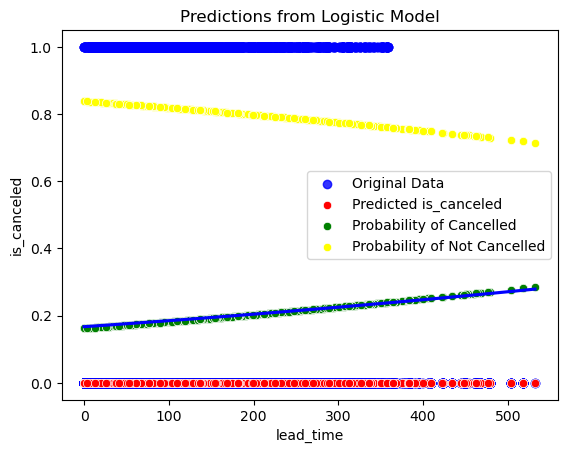

In [103]:
sns.regplot(x = "lead_time", y = "is_canceled", data = df, color = "blue", ci = None, logistic = True, label="Original Data")
sns.scatterplot(x = "lead_time", y = "y_pred", data = test_set, color = "red", label="Predicted is_canceled")
sns.scatterplot(x = "lead_time", y = "y_proba_yes", data = test_set, color = "green", label="Probability of Cancelled")
sns.scatterplot(x = "lead_time", y = "y_proba_no", data = test_set, color = "yellow", label="Probability of Not Cancelled")
plt.title("Predictions from Logistic Model")
plt.legend()
plt.show()

In [105]:
### Create model with no independent variables to help with model evaluation for statistical significance ###

y2 = df[['is_canceled']]

# All independent variables for initial model based on selection criteria above
X2 = df[[]]

intercept_only_formula = 'is_canceled ~ 1'
intercept_only_model = logit(formula=intercept_only_formula, data=df).fit()

conf_matrix2 = intercept_only_model.pred_table()

print(intercept_only_model.summary())
acc_scr = (conf_matrix2[0,0] + conf_matrix2[1,1]) / (conf_matrix2[0,0] + conf_matrix2[1,1] + conf_matrix2[1,0] + conf_matrix2[0,1])
sens_scr = (conf_matrix2[0,0]) / (conf_matrix2[1,0] + conf_matrix2[1,1])
precision_scr = conf_matrix2[1,1] / (conf_matrix2[1,1] + conf_matrix2[1,0])
f1_scr = 2 * (precision_scr * sens_scr) / (precision_scr + sens_scr)
print('\nAccuracy Score: {}'.format(acc_scr))
print('Sensitivity Score: {}'.format(sens_scr))
print('F1 Score: {}'.format(f1_scr))

Optimization terminated successfully.
         Current function value: 0.486918
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:            is_canceled   No. Observations:                13487
Model:                          Logit   Df Residuals:                    13486
Method:                           MLE   Df Model:                            0
Date:                Sat, 31 Aug 2024   Pseudo R-squ.:               7.040e-11
Time:                        12:39:18   Log-Likelihood:                -6567.1
converged:                       True   LL-Null:                       -6567.1
Covariance Type:            nonrobust   LLR p-value:                       nan
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.4469      0.022    -65.983      0.000      -1.490      -1.404

Accuracy Score: 0.8095202787

In [124]:
# Log Likelihood Ratio Test
from scipy.stats import chi2

model1_ll = -4538.8
model2_ll = -6567.1
model1_df = 1
model2_df = 0

likelihood_diff = model1_ll - model2_ll
likelihood_ratio = likelihood_diff * 2
degrees_of_freedom = model1_df - model2_df
p_value = chi2.sf(likelihood_ratio, degrees_of_freedom)

print(p_value)

0.0


In [126]:
print("AIC of lead_time model training data: ", updated_model.aic)
print("AIC of intercept-only model: ", intercept_only_model.aic)

AIC of lead_time model training data:  9081.601382270075
AIC of intercept-only model:  13136.121225815707


AUC: 0.5588801201108715 



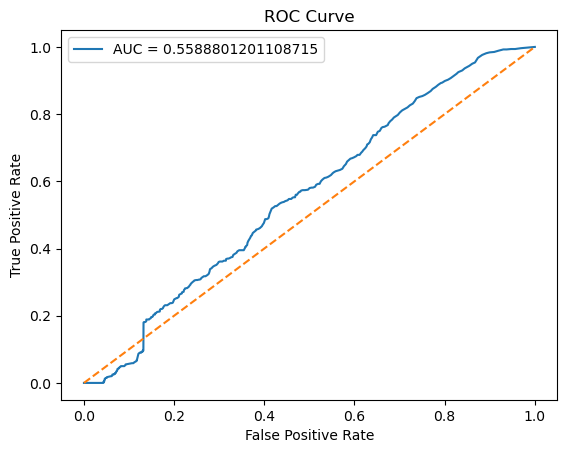

In [348]:
### Additional Model Evaluation ###

from sklearn.metrics import roc_curve, roc_auc_score

# Predict probabilities for the test set
y_prob = reduced_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

print("AUC:", auc, '\n')

plt.plot(fpr, tpr, label="AUC = {}".format(auc))
plt.plot([0, 1], [0, 1], linestyle="--")  # Random classifier
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()